# Clinical NLP over Italian Hospital Records

*NLP4DH exam project.* The corpus is 857 pseudonymised hospital encounters, each with three Italian
reports: discharge therapy, admission therapy and anamnesis. The pipeline turns those reports into
structured facts, derives safety alerts from them with symbolic rules, publishes everything as an RDF
graph and uses a small local language model for extraction and for three neuro-symbolic demonstrations.

**Contents**

1. Setup and data
2. Dataset exploration
3. Drug resources
4. Discharge therapy: template extraction
5. Admission therapy: few-shot extraction
6. Anamnesis: NER, context and UMLS linking
7. Symbolic alert engine
8. Evaluation
9. RDF graph and SPARQL
10. Local LLM demonstrations
11. Discussion

## 1. Setup and data

In [1]:
import json
import os
import re
import textwrap
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import joblib
import numpy as np
import ollama
import pandas as pd
import spacy
import torch
from gliner import GLiNER
from IPython.display import display
from medspacy.context import ConTextRule
from rdflib import Graph, Literal, Namespace, RDF, RDFS, URIRef
from rdflib.plugins.sparql import prepareQuery
from scipy import sparse
from sentence_transformers import SentenceTransformer
from sklearn.metrics import confusion_matrix, f1_score, precision_recall_fscore_support
from spacy import displacy
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()   

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
ANNOTATION_DIR = DATA_DIR / "annotations"
EXTERNAL_DIR = DATA_DIR / "external"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Models. GLiNER tags the anamnesis, E5 ranks UMLS candidates, Qwen is the local instruction model
# used both for admission extraction (Section 5) and for the demonstrations of Section 10.
SPACY_MODEL = "it_core_news_lg"
GLINER_MODEL = "urchade/gliner_multi-v2.1"
EMBEDDER_MODEL = "intfloat/multilingual-e5-small"
LOCAL_LLM_MODEL = "qwen2.5:3b-instruct"

NER_THRESHOLD = 0.45          # GLiNER span confidence

# UMLS Metathesaurus used locally: build_umls_index.py
# distils the licensed archive once into an alias table and a TF-IDF index over it.
UMLS_VERSION = "2026AA"
UMLS_CACHE_DIR = EXTERNAL_DIR / "umls_cache"
UMLS_INDEX_DIR = EXTERNAL_DIR / "umls_index"
UMLS_MAX_CANDIDATES = 15      # candidate concepts kept per mention

UMLS_COSINE_FLOOR = 0.90      

pd.set_option("display.max_colwidth", 90)
print(f"device: {DEVICE} | UMLS release {UMLS_VERSION}")

device: cuda | UMLS release 2026AA


In [3]:
with open(DATA_DIR / "pazienti_con_terapia_uscita_testuale.json", encoding="utf-8") as f:
    patients = json.load(f)

patient_by_oid = {p["encOid"]: p for p in patients}

T_ANAMNESIS = "Anamnesi"
T_ADMISSION = "Terapia medica all'ingresso"
T_DISCHARGE = "Terapia alla Dimissione"


def report(patient, report_type):
    """The report record of a given type, or None when the patient has no such report."""
    return next((r for r in patient["referti"] if r["tipo"] == report_type), None)


def report_text(patient, report_type):
    """Free text of a report type, empty string when the report is missing."""
    record = report(patient, report_type)
    return (record["testo"] or "") if record else ""


def wrap(text, width=100):
    """Wrap long free text for readable output, keeping the existing line breaks."""
    return "\n".join(textwrap.fill(line, width=width) if line.strip() else line
                     for line in str(text).splitlines())


print(f"loaded {len(patients)} patients, {sum(len(p['referti']) for p in patients)} reports")

loaded 857 patients, 2571 reports


### Annotated patients

50 of the 857 patients carry reference annotations. Four of them are few-shot demonstrations of
Section 5, so metrics are reported on the remaining 46; a fifth, unannotated patient completes the
prompt with a report layout the annotated four do not show.

In [4]:
ANNOTATED_PATIENTS = sorted(int(x) for x in
                            pd.read_csv(ANNOTATION_DIR / "gold_report_manifest.csv").encOid.unique())


FEW_SHOT_PATIENTS = [10149591, 10102082, 10083544, 10075109]
AUXILIARY_FEW_SHOT_PATIENT = 10075110
EVAL_PATIENTS = sorted(set(ANNOTATED_PATIENTS) - set(FEW_SHOT_PATIENTS))
assert not set(FEW_SHOT_PATIENTS) & set(EVAL_PATIENTS)
assert AUXILIARY_FEW_SHOT_PATIENT not in ANNOTATED_PATIENTS

print(f"annotated: {len(ANNOTATED_PATIENTS)} patients | few-shot demonstrations: "
      f"{len(FEW_SHOT_PATIENTS)} + 1 auxiliary | evaluation: {len(EVAL_PATIENTS)}")

annotated: 50 patients | few-shot demonstrations: 4 + 1 auxiliary | evaluation: 46


## 2. Dataset exploration

In [5]:
lengths = pd.DataFrame([{"report_type": r["tipo"], "characters": len(r["testo"] or "")}
                        for p in patients for r in p["referti"]])

print(f"patients: {len(patients)} | patients with exactly three reports: "
      f"{sum(len(p['referti']) == 3 for p in patients)}")
display(lengths.groupby("report_type").characters.agg(["count", "min", "median", "mean", "max"]).round(0).astype(int))

patients: 857 | patients with exactly three reports: 857


,count,min,median,mean,max
report_type,,,,,
Anamnesi,857,222,1693,2239,15968
Terapia alla Dimissione,857,15,649,679,2281
Terapia medica all'ingresso,857,4,284,318,1899


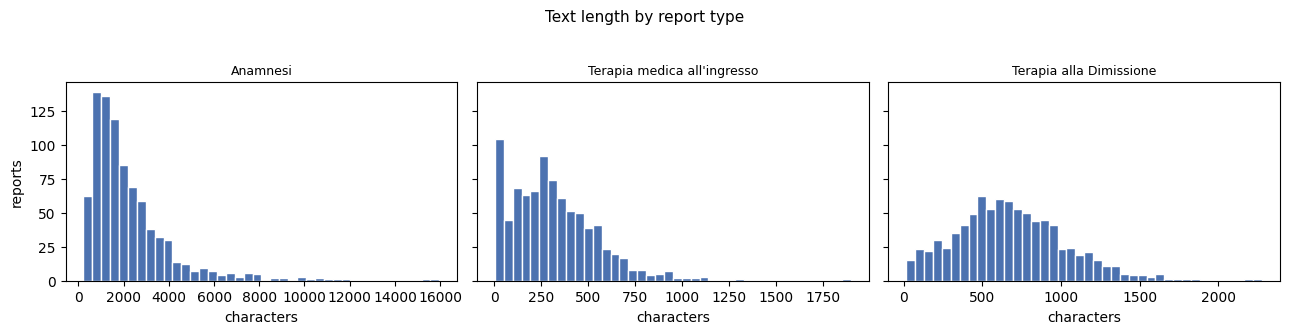

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)

for ax, report_type in zip(axes, [T_ANAMNESIS, T_ADMISSION, T_DISCHARGE]):
    ax.hist(lengths.loc[lengths.report_type == report_type, "characters"],
            bins=40, color="#4C72B0", edgecolor="white")
    ax.set_title(report_type, fontsize=9)
    ax.set_xlabel("characters")

axes[0].set_ylabel("reports")
fig.suptitle("Text length by report type", y=1.03, fontsize=11)
plt.tight_layout()
plt.show()

In [7]:
def show(title, text, width=340):
    body = (text[:width] + "\u2026") if len(text) > width else (text or "(empty)")
    print(f"### {title}\n{wrap(body)}\n")


def first_patient_with(report_type, predicate):
    """The first patient in the cohort whose report of `report_type` satisfies `predicate`."""
    return next(p for p in patients if predicate(report_text(p, report_type)))


def has_untemplated_entry(text):
    """True if a `;`-separated entry states a posology without the `Product: dose form` colon."""
    return any(":" not in entry and re.search(r"\d", entry)
               for entry in text.split(";") if entry.strip())


show("Terapia alla Dimissione - quoted template, including a combination product",
     report_text(patients[0], T_DISCHARGE))
show("Terapia medica all'ingresso - semi-structured product list",
     report_text(patients[0], T_ADMISSION))
show("Terapia medica all'ingresso - untemplated entries in running text",
     report_text(first_patient_with(T_ADMISSION, has_untemplated_entry), T_ADMISSION))
show("Terapia medica all'ingresso - no home therapy",
     report_text(first_patient_with(T_ADMISSION, lambda t: "essuna terapia" in t), T_ADMISSION))
show("Terapia medica all'ingresso - non-drug interventions among the drugs",
     report_text(first_patient_with(T_ADMISSION, lambda t: re.search(r"Ossigeno|NIV|CPAP", t)), T_ADMISSION))
show("Anamnesi - narrative prose", report_text(patients[0], T_ANAMNESIS))

### Terapia alla Dimissione - quoted template, including a combination product
"Acido folico (Folina cps. molli 5 mg): da assumere 5 mg (ore 15)" "Tiamina (Benerva cpr.gastr. 300
mg): da assumere 300 mg (ore 15)" "Colecalciferolo (Annova cp.riv. 7000 UI): da assumere 7000 UI
(ore 13), ogni 6 giorni (a partire da 2 giorni fa)" "Clopidogrel/acido acetilsalicilico (Duoplavin
cp.riv. 75 mg): da assumere 75/100 mg (ore 1…

### Terapia medica all'ingresso - semi-structured product list
Atorvastatina sa: 80 mg cp.riv. /die (ore 22) ; Clopidogrel zen: 75 mg cp.riv. /die (ore 12) ;
Omnic: 0,4 mg cps. rigide rm /die (ore 22) ; Folina: 5 mg cps. molli /die (ore 15) ; Benerva: 300 mg
cpr.gastr. /die (ore 15) ; Annova: 7000 UI cp.riv. (ore 13) ogni 6 giorni ;

### Terapia medica all'ingresso - untemplated entries in running text
Eutirox: 25 mcg cpr. divisibili /die (ore 6) ; Blopress: 16 mg cpr. divisibili /die (ore 8) ;
Plavix: 75 mg cp.riv. /die (ore 8) ; Fleiderina: 150 mg cps. rigide rp /die (o

In [8]:
# The four phenomena the context stage has to handle, each shown on the sentence that contains it.
def first_sentence_matching(required, forbidden=None):
    """The first anamnesis sentence in the cohort matching every pattern in `required` and none in
    `forbidden`, with its patient id."""
    forbidden = forbidden or []
    for patient in patients:
        for sentence in re.split(r"(?<=[.!?])\s+", report_text(patient, T_ANAMNESIS)):
            if (all(re.search(p, sentence, flags=re.IGNORECASE) for p in required)
                    and not any(re.search(p, sentence, flags=re.IGNORECASE) for p in forbidden)):
                return patient["encOid"], sentence.strip()
    return None, ""


NEGATION_CUE = r"\bnega\b|\bnon\b|\bassenza\b|\bnessun"
FAMILY_CUE = r"\bfamiliarit"


phenomena = {
    "negation": ([r"\bnega\b"], None),
    "affirmed family history": ([FAMILY_CUE], [NEGATION_CUE]),
    "negated family history": ([FAMILY_CUE, NEGATION_CUE], None),
    "uncertainty": ([r"\bsospett[oa]\b|\bverosimile\b"], None),
}

display(pd.DataFrame([{"phenomenon": name, "encOid": oid, "sentence": sentence}
                      for name, (required, forbidden) in phenomena.items()
                      for oid, sentence in [first_sentence_matching(required, forbidden)]]).set_index("phenomenon"))

,encOid,sentence
phenomenon,,
negation,10216091,Nega allergia a farmaci e/o alimenti.
affirmed family history,10239553,Familiarita per CAD.
negated family history,10175544,Nega familiarita per diabete o altre cardiopatie congenite.
uncertainty,10247783,Sospetto flail della porzione S1 del lembo settale.


## 3. Drug resources

**Task.** Build the drug knowledge the rest of the notebook joins on.

**Output.** `products`, `ingredients`, `interactions` and `contraindications`.


### What each identifier is for

| Identifier | Represents | Used for |
|---|---|---|
| `ingredient_key` | canonical local ingredient identity | duplicates, allergy/intolerance |
| `atc_code` | product therapeutic/anatomical classification | RDF hierarchy / SPARQL |
| `rxcui` | RxNorm drug concept | MED-RT drug side |
| `ddinter_id` | DDInter drug identifier | drug-drug interactions |
| `umls_cui` | clinical concept | anamnesis condition linking / MED-RT condition side |

Product-level and ingredient-level information are kept apart:

```
AIFA product              canonical ingredient
  product_name              ingredient_key
  ingredients               preferred_label
  atc_code                  rxcui
                            ddinter_id
```

ATC classifies a *registered product*. The same substance carries different codes inhaled, nasal or
topical, so it is a property of the prescription, taken from the product the clinician named and
left `None` when the product is not in the registry.

### 3.1 Lexical normalisation

`normalize_name` folds case and whitespace; 

`ingredient_key` additionally
removes the salt, hydrate and dose material that separates a written mention from the registry's name
for the same molecule;

`preferred_label` is a display string and is never used as an identity.

In [9]:
def normalize_name(value):
    """Case- and whitespace-normalised surface form."""
    return re.sub(r"\s+", " ", str(value).strip().lower())


# Counterions, esters and hydration states. A report and the registry can name different salts of
# one molecule and the rules join on the molecule, so they reduce to one key. The trailing-ion
# pattern is position-aware because these ions can also be the active substance ("calcio carbonato"
# keeps calcio, "atorvastatina calcio" drops it).
SALT_OR_HYDRATE = re.compile(
    r"\b(cloridrato|idrocloruro|besilato|mesilato|maleato|fumarato|emifumarato|tartrato|succinato|"
    r"solfato|acetato|dipropionato|furoato|valerato|nitrato|fosfato|citrato|bromuro|sodico|sodica|"
    r"calcico|potassico|anidro|\w*idrato)\b", re.I)

TRAILING_ION = re.compile(r"\b(?:sale\s+)?di\s+(?:sodio|potassio|calcio|magnesio|zinco)\b"
                          r"|\s+(?:sodio|potassio|calcio|magnesio|zinco)\s*$", re.I)

# The discharge template sometimes leaves posology inside the ingredient field
# ("Pantoprazolo 20 mg 1 cp al mattino"), so the key has to cut it.
DOSE_TAIL = re.compile(r"\b(?:mg|mcg|ml|ui|cp|cpr|cps|gtt|fl|bustin[ae]|die|ore|da assumere)\b.*$", re.I)


def ingredient_key(name):
    """Canonical identity of an active ingredient: the one key every drug rule joins on."""
    text = DOSE_TAIL.sub(" ", normalize_name(name))
    text = re.sub(r"\s+\d+(?:[.,]\d+)?\s*$", " ", text)          # a trailing number, usually posology here
    text = TRAILING_ION.sub(" ", SALT_OR_HYDRATE.sub(" ", text))
    return re.sub(r"\s+", " ", text).strip() or normalize_name(name)


assert ingredient_key("ATORVASTATINA CALCIO TRIIDRATO") == "atorvastatina"
assert ingredient_key("Pantoprazolo 20 mg 1 cp al mattino h 7") == "pantoprazolo"
assert ingredient_key("Macrogol 3350") == "macrogol"             # the registry entry is "Macrogol"

### 3.2 Resource tables

`products` and `ingredients` come from the Italian medicines agency (AIFA) registry. `interactions`
is the DDInter 2.0 pairwise table. `contraindications` is MED-RT's `ci_with` relation, already
aligned to UMLS concepts.

In [10]:
# AIFA product registry: one row per registered product name, with its active ingredients and, when
# the registry assigns exactly one, its ATC code.
packages = pd.read_parquet(EXTERNAL_DIR / "aifa" / "normalized" / "aifa_confezioni.parquet")
by_product = {}

for name, actives, atc in zip(packages.DENOMINAZIONE, packages.PA_ASSOCIATI, packages.CODICE_ATC):
    if pd.isna(name):
        continue

    entry = by_product.setdefault(normalize_name(name), {"product_name": str(name), "ingredients": set(), "atc": set()})

    if pd.notna(actives):
        entry["ingredients"].update(part.strip() for part in str(actives).split("/") if part.strip())

    if pd.notna(atc):
        entry["atc"].add(str(atc))

products = pd.DataFrame([{"product_key": key,
                          "product_name": entry["product_name"],
                          "ingredients": sorted(entry["ingredients"]),
                          "atc_code": next(iter(entry["atc"])) if len(entry["atc"]) == 1 else None}
                         for key, entry in by_product.items()])

PRODUCT_ATC = dict(zip(products.product_key, products.atc_code))
PRODUCT_INGREDIENTS = dict(zip(products.product_key, products.ingredients))

print(f"AIFA products: {len(products)} | with a single ATC code: {int(products.atc_code.notna().sum())}")
display(products.head(3))

AIFA products: 10504 | with a single ATC code: 10343


,product_key,product_name,ingredients,atc_code
0,tisana kelemata,TISANA KELEMATA,"[SENNA ESTRATTO SECCO, SENNA FOGLIA]",A06AB06
1,magnesia effervescente sella,MAGNESIA EFFERVESCENTE SELLA,[MAGNESIO IDROSSIDO],A02AA04
2,rinazina,RINAZINA,[NAFAZOLINA NITRATO],R01AA08


In [11]:
# Ingredient crosswalk: the canonical ingredient and the two external identifiers the rules need.
# `lookup_key` is `ingredient_key(preferred_label)`.
crosswalk = pd.read_csv(EXTERNAL_DIR / "ingredient_crosswalk.csv")
ingredients = pd.DataFrame({"ingredient_key": crosswalk.lookup_key.astype(str),
                            "preferred_label": crosswalk.preferred_label.astype(str),
                            "rxcui": pd.to_numeric(crosswalk.RXCUI, errors="coerce").astype("Int64"),
                            "ddinter_id": crosswalk.DDINTER.astype("string")})

assert ingredients.ingredient_key.is_unique
assert (ingredients.preferred_label.map(ingredient_key) == ingredients.ingredient_key).all()

PREFERRED_LABEL = dict(zip(ingredients.ingredient_key, ingredients.preferred_label))
KNOWN_INGREDIENTS = set(ingredients.ingredient_key)
RXCUI = {k: int(v) for k, v in zip(ingredients.ingredient_key, ingredients.rxcui) if pd.notna(v)}
DDINTER_ID = {k: str(v) for k, v in zip(ingredients.ingredient_key, ingredients.ddinter_id) if pd.notna(v)}

print(f"canonical ingredients: {len(ingredients)} | with an RxCUI: {len(RXCUI)} | with a DDInter id: {len(DDINTER_ID)}")
display(ingredients.head(3))

canonical ingredients: 2304 | with an RxCUI: 1548 | with a DDInter id: 587


,ingredient_key,preferred_label,rxcui,ddinter_id
0,131-i iodomethyl norcholesterol,131-I Iodomethyl Norcholesterol,<NA>,<NA>
1,[18f]psma-1007,[18F]Psma-1007,2586016,<NA>
2,abacavir,Abacavir,190521,DDInter1


In [12]:
# DDInter 2.0: severity per unordered pair of drug identifiers. One pair can be listed twice with
# different severities, so the higher one is kept.
SEVERITY_RANK = {"Major": 3, "Moderate": 2, "Minor": 1}
interaction_rows = pd.read_csv(EXTERNAL_DIR / "ddinter" / "normalized" / "safety" / "drug_interactions.csv")
interactions = {}

for left, right, severity in zip(interaction_rows.ddinter_id_1, interaction_rows.ddinter_id_2,
                                 interaction_rows.severity):
    pair = frozenset((left, right))

    if SEVERITY_RANK.get(severity, 0) > SEVERITY_RANK.get(interactions.get(pair), 0):
        interactions[pair] = severity

print(f"DDInter pairs: {len(interactions)} | {Counter(interactions.values()).most_common()}")

DDInter pairs: 130422 | [('Moderate', 96675), ('Major', 26914), ('Minor', 6833)]


**MED-RT alignment, done once.** MED-RT states a contraindication as (RxCUI, MeSH disease
descriptor), while the anamnesis linker of Section 6 produces UMLS CUIs. The MeSH-to-UMLS lookup was
run once against the UMLS source-identifier search and its outcome per descriptor is cached in
`data/external/umls_cache/medrt_disease_cuis.parquet`. A descriptor that returned several concepts
with no name agreement is left unmapped. The result is one flat table of `(rxcui, condition_cui)` pairs.

In [13]:
medrt = pd.read_csv(EXTERNAL_DIR / "rx" / "rxclass" / "medrt_contraindications.csv")
ci_with = medrt[(medrt.rela == "ci_with") & (medrt.class_type == "DISEASE")].drop_duplicates(["rxcui", "class_id"])

mesh_to_cui = pd.read_parquet(UMLS_CACHE_DIR / "medrt_disease_cuis.parquet")
mesh_to_cui = mesh_to_cui[mesh_to_cui.umls_release == UMLS_VERSION]
print("MeSH descriptor to UMLS concept:")
display(mesh_to_cui.mapping_status.value_counts().rename("descriptors").to_frame())

resolved = mesh_to_cui[mesh_to_cui.mapping_status.isin(["mapped_unique", "mapped_by_name"])
                       & mesh_to_cui.disease_cui.notna()]
contraindications = (ci_with.merge(resolved[["class_id", "disease_cui", "umls_label"]], on="class_id")
                     .rename(columns={"disease_cui": "condition_cui", "umls_label": "condition_label"})
                     [["rxcui", "condition_cui", "condition_label"]])

CONTRAINDICATION_PAIRS = {(int(r.rxcui), r.condition_cui) for r in contraindications.itertuples()}
CONTRAINDICATION_LABEL = {(int(r.rxcui), r.condition_cui): r.condition_label for r in contraindications.itertuples()}

print(f"MED-RT ci_with pairs: {len(ci_with)} over {ci_with.class_id.nunique()} MeSH descriptors | "
      f"aligned to a UMLS concept: {len(contraindications)}")
display(contraindications.head(3))

MeSH descriptor to UMLS concept:


,descriptors
mapping_status,
mapped_unique,122
mapped_by_name,79
mapped_ambiguous,19


MED-RT ci_with pairs: 772 over 220 MeSH descriptors | aligned to a UMLS concept: 737


,rxcui,condition_cui,condition_label
0,167,C0001122,Acidosis
1,167,C0001621,Adrenal Gland Diseases
2,167,C0013182,Drug Allergy


## 4. Discharge therapy: template extraction

**Task.** Turn *Terapia alla Dimissione* into one row per prescription.

**Method.** Each prescription is a quoted entry with the shape
`Principio attivo (Prodotto forma dose): da assumere <posologia>`. Position declares the role of each
field, so a regex reads it; nothing has to be discovered.

**Output.** `prescriptions`, with `encOid`, `product_name`, `ingredients`, `dose_text`,
`instructions` and `atc_code`.


In [14]:
# `ENTRY` splits an entry at its first colon; `PRODUCT_TAIL` takes the LAST parenthetical of the 
# head as the commercial product; `STRENGTH` reads a dose as written, combination strengths included.
ENTRY = re.compile(r"^(?P<head>[^:]+):(?P<body>.*)$", re.S)
PRODUCT_TAIL = re.compile(r"\(([^()]*)\)([^()]*)$")
FORM_LEAD = re.compile(r"\b(cp|cerott|soluz|sosp|comp|bust|gtt|fial|fl|capsul|ovul|crema|pomata|"
                       r"collirio|spray|scir|granul|polvere|nebuliz)", re.I)
STRENGTH = re.compile(r"\d+(?:[.,]\d+)?(?:\s*/\s*\d+(?:[.,]\d+)?)*\s*(?:mg/d|mg|mcg|g|UI|U|ml|%)", re.I)
NON_DRUG_THERAPY = re.compile(r"\b(ossigeno|niv|cpap|cannula nasale|maschera|ventil)", re.I)
NO_THERAPY = re.compile(r"nessun|non assume|nulla|assente", re.I)


def parse_prescription(entry):
    """One quoted therapy entry -> a prescription dict, or None when the entry is not one."""
    entry = entry.strip()

    if not entry or NON_DRUG_THERAPY.search(entry.split("(")[0]):   
        return None

    match = ENTRY.match(entry)

    if not match:
        return None

    head, body = match.group("head"), match.group("body").strip()
    product = PRODUCT_TAIL.search(head)
    product_text = f"{product.group(1)} {product.group(2)}".strip() if product else None
    ingredient_field = re.sub(r"\([^()]*\)", " ", head[:product.start()] if product else head).strip()
    ingredient_list = [part.strip() for part in ingredient_field.split("/") if part.strip()]

    if not ingredient_list:
        return None

    product_name = None

    if product_text:
        form = FORM_LEAD.search(product_text)
        product_name = (product_text[:form.start()] if form else STRENGTH.sub("", product_text)).strip() or None

    instructions = re.sub(r"^\s*da assumere\s*", "", body).strip()
    dose = STRENGTH.search(instructions) or (STRENGTH.search(product_text) if product_text else None)

    return {"product_name": product_name, "ingredients": ingredient_list,
            "dose_text": dose.group(0) if dose else None, "instructions": instructions or None}


example = ('Clopidogrel/acido acetilsalicilico (Duoplavin cpr.riv. 75 mg): da assumere 75/100 mg (ore 19)')
print(example)
print(parse_prescription(example))

Clopidogrel/acido acetilsalicilico (Duoplavin cpr.riv. 75 mg): da assumere 75/100 mg (ore 19)
{'product_name': 'Duoplavin', 'ingredients': ['Clopidogrel', 'acido acetilsalicilico'], 'dose_text': '75/100 mg', 'instructions': '75/100 mg (ore 19)'}


In [15]:
# Pass over the cohort. Prescriptions are quoted; a report that quotes nothing and states an
# absence of therapy contributes no row.
rows = []

for patient in patients:
    text = report_text(patient, T_DISCHARGE)
    entries = re.findall(r'"([^"]*)"', text)

    if not entries:
        if not text.strip() or NO_THERAPY.search(text):
            continue

        entries = [text]

    for entry in entries:
        parsed = parse_prescription(entry)

        if parsed is not None:
            rows.append({"encOid": patient["encOid"], **parsed,
                         "atc_code": PRODUCT_ATC.get(normalize_name(parsed["product_name"] or ""))})

prescriptions = pd.DataFrame(rows)
prescriptions["prescription_id"] = prescriptions.index

print(f"prescriptions: {len(prescriptions)} over {prescriptions.encOid.nunique()} patients")
print(f"  combination products (more than one ingredient): {int((prescriptions.ingredients.map(len) > 1).sum())}")
print(f"  with an ATC code from the product registry: {prescriptions.atc_code.notna().sum()} "
      f"({prescriptions.atc_code.notna().mean():.0%})")
display(prescriptions[prescriptions.ingredients.map(len) > 1].head(4))

prescriptions: 6351 over 847 patients
  combination products (more than one ingredient): 705
  with an ATC code from the product registry: 4698 (74%)


,encOid,product_name,ingredients,dose_text,instructions,atc_code,prescription_id
3,10216091,Duoplavin,"[Clopidogrel, acido acetilsalicilico]",75/100 mg,75/100 mg (ore 19),B01AC30,3
9,10175544,Duoplavin,"[Clopidogrel, acido acetilsalicilico]",75/100 mg,75/100 mg (ore 20),B01AC30,9
11,10223315,Rosumibe,"[Rosuvastatina, ezetimibe]",10/10 mg,10/10 mg (ore 22),C10BA06,11
12,10223315,Reaptan,"[Perindopril, amlodipina]",10/10 mg,10/10 mg (ore 8),C09BB04,12


In [16]:
# The ingredient view: one row per active ingredient of a prescription, carrying the identifiers the
# alert engine joins on. A combination product contributes one row per ingredient and keeps its
# prescription_id, which is what lets Section 7 tell a duplicate prescription from a combination.
prescribed = (prescriptions.explode("ingredients")
              .rename(columns={"ingredients": "ingredient"})
              .dropna(subset=["ingredient"])
              .reset_index(drop=True))
prescribed["ingredient_key"] = prescribed.ingredient.map(ingredient_key)
prescribed["preferred_label"] = prescribed.ingredient_key.map(PREFERRED_LABEL)
prescribed["rxcui"] = prescribed.ingredient_key.map(RXCUI).astype("Int64")
prescribed["ddinter_id"] = prescribed.ingredient_key.map(DDINTER_ID).astype("string")

prescriptions.to_parquet(OUTPUT_DIR / "discharge_prescriptions.parquet")

print(f"prescribed ingredient rows: {len(prescribed)} | distinct ingredients: {prescribed.ingredient_key.nunique()}")
display(pd.Series({
    "known to the AIFA ingredient crosswalk": prescribed.preferred_label.notna().mean(),
    "with an RxCUI (MED-RT drug side)": prescribed.rxcui.notna().mean(),
    "with a DDInter id (interaction rule)": prescribed.ddinter_id.notna().mean(),
}, name="share of ingredient rows").to_frame().style.format("{:.1%}"))

display(prescribed.head(5))

prescribed ingredient rows: 7127 | distinct ingredients: 384


,share of ingredient rows
known to the AIFA ingredient crosswalk,94.8%
with an RxCUI (MED-RT drug side),91.3%
with a DDInter id (interaction rule),48.4%


,encOid,product_name,ingredient,dose_text,instructions,atc_code,prescription_id,ingredient_key,preferred_label,rxcui,ddinter_id
0,10216091,Folina,Acido folico,5 mg,5 mg (ore 15),B03BB01,0,acido folico,Acido Folico,4511,<NA>
1,10216091,Benerva,Tiamina,300 mg,300 mg (ore 15),A11DA01,1,tiamina,Tiamina Cloridrato,10454,<NA>
2,10216091,Annova,Colecalciferolo,7000 UI,"7000 UI (ore 13), ogni 6 giorni (a partire da 2 giorni fa)",A11CC05,2,colecalciferolo,Colecalciferolo,2418,<NA>
3,10216091,Duoplavin,Clopidogrel,75/100 mg,75/100 mg (ore 19),B01AC30,3,clopidogrel,Clopidogrel,32968,DDInter413
4,10216091,Duoplavin,acido acetilsalicilico,75/100 mg,75/100 mg (ore 19),B01AC30,3,acido acetilsalicilico,Acido Acetilsalicilico,1191,<NA>


## 5. Admission therapy: few-shot extraction

**Task.** Extract one medication label per medication entry in *Terapia medica all'ingresso*: every entry is annotated, so a drug written in several entries carries one mention per entry. Where an
entry names both an active ingredient and an explicit product name, the product name is the target;
otherwise the name the entry provides is. Dose, formulation, schedule and instructions are outside the
span and non-pharmacological interventions such as oxygen, NIV and CPAP are not medications.

**Method.** Few-shot generative information extraction with the local instruction model; a mention is
kept only if it can be located in the source text.

**Output.** `admission_mentions`, one row per grounded mention with its character offsets.

**Rationale.** Unlike the discharge report, the admission text has no stable template: it mixes
product lists with colons, bare lowercase lists, template-style entries naming active ingredients,
empty statements and non-drug interventions.

The extractor is run on the 46 evaluation patients. The demonstration patients are inside the
prompt and admission therapy feeds no downstream stage, so the section exists for measurement.

```
admission text -> few-shot extraction -> drug mentions -> evaluation
```

In [17]:
# Entry point to the local model, reused by this section and by Section 10.
local_llm = ollama.Client()


def generate_local(prompt, system=None, tools=None):
    """One call to the local instruction model. Returns the response message."""
    messages = ([{"role": "system", "content": system}] if system else []) + [{"role": "user", "content": prompt}]
    response = local_llm.chat(model=LOCAL_LLM_MODEL, messages=messages, tools=tools,
                              options={"temperature": 0, "num_ctx": 4096})
    return response["message"]


print(f"local model: {LOCAL_LLM_MODEL} (temperature 0)")

local model: qwen2.5:3b-instruct (temperature 0)


Five examples, chosen for the variants they show: an empty therapy, manufacturer-suffixed product
names, combination products, an irregular entry written without a colon and a report written in the
discharge template `Principio attivo (Prodotto forma dose)`, where the label is the product inside
the parentheses. None of the five lists oxygen or ventilation, so that case is stated in the
instruction rather than demonstrated.

In [18]:
FEW_SHOT_ANSWERS = {
    10149591: [],
    10102082: ["Rivaroxaban doc", "Flecainide auro", "Lobivon"],
    10083544: ["Triatec hct", "Congescor", "Ezevast", "Pantoprazolo sand", "Furosemide l.f.m.", "Mirebax"],
    10075109: ["Eliquis", "Reaptan", "Sequacor", "Lanoxin", "Omeprazolo my", "enantone"],
    # The label is the product inside the parentheses, except
    # for the one entry that names no product.
    10075110: ["Omeprazolo my", "Deltacortene", "Bisoprololo", "Clopidogrel aur", "Jardiance",
               "Lasix", "Entresto", "Eliquis", "Colchicina lirca", "Inspra", "Cholecomb",
               "Humalog", "Lantus", "dibase", "kinret"],
}

EXTRACTION_INSTRUCTION = (
    "Estrai i nomi dei farmaci della terapia domiciliare. "
    "Se una voce contiene sia il principio attivo sia un nome commerciale esplicito, "
    "estrai il nome commerciale. "
    "Rispondi SOLO con una lista JSON di stringhe copiate esattamente dal testo. "
    "Non includere dosi, orari, forme farmaceutiche o istruzioni. "
    "Non includere ossigeno, NIV, CPAP o altri presidi non farmacologici. "
    "Se non ci sono farmaci, rispondi []."
)


def demonstration_text(oid):
    """The report as the prompt shows it. One demonstration repeats its whole list and the second
    copy teaches nothing while doubling the length of the prompt."""
    text = report_text(patient_by_oid[oid], T_ADMISSION)
    repeat = text.find(text[:20], 1)

    return text[:repeat] if repeat > 0 else text


FEW_SHOT_BLOCK = "\n\n".join(
    f"TESTO: {demonstration_text(oid)}\n"
    f"FARMACI: {json.dumps(FEW_SHOT_ANSWERS[oid], ensure_ascii=False)}"
    for oid in FEW_SHOT_PATIENTS + [AUXILIARY_FEW_SHOT_PATIENT])


def extraction_prompt(text):
    return f"{FEW_SHOT_BLOCK}\n\nTESTO: {text}\nFARMACI:"


print(wrap(EXTRACTION_INSTRUCTION))
print()
print(wrap(FEW_SHOT_BLOCK))

Estrai i nomi dei farmaci della terapia domiciliare. Se una voce contiene sia il principio attivo
sia un nome commerciale esplicito, estrai il nome commerciale. Rispondi SOLO con una lista JSON di
stringhe copiate esattamente dal testo. Non includere dosi, orari, forme farmaceutiche o istruzioni.
Non includere ossigeno, NIV, CPAP o altri presidi non farmacologici. Se non ci sono farmaci,
rispondi [].

TESTO: Nessuna terapia domiciliare.
FARMACI: []

TESTO: Rivaroxaban doc: 20 mg cp.riv. /die (ore 14) ; Flecainide auro: 50 mg cpr. divisibili /die
(ore 8) 50 mg cpr. divisibili /die (ore 20) ; Lobivon: 2,5 mg cpr. divisibili /die (ore 8) ;
FARMACI: ["Rivaroxaban doc", "Flecainide auro", "Lobivon"]

TESTO: Triatec hct: 5/25 mg cpr. divisibili /die (ore 8) ; Congescor: 1,25 mg cp.riv. /die (ore 8) ;
Ezevast: 10/40 mg cp.riv. /die (ore 22) ; Pantoprazolo sand: 20 mg cpr.gastr. lun-mer-ven-dom (ore
7) ; Furosemide l.f.m.: 25 mg cpr. mar-ven (ore 8) ; Mirebax: 20 mg cp.riv. /die (ore 13) ultim

In [19]:
def parse_json_list(answer):
    """The JSON list inside a model answer, or an empty list when there is none."""
    start, end = answer.find("["), answer.rfind("]")

    if start < 0 or end < start:
        return []

    try:
        parsed = json.loads(answer[start:end + 1])
    except json.JSONDecodeError:
        return []

    return [x for x in parsed if isinstance(x, str)] if isinstance(parsed, list) else []


def ground_mentions(text, mentions):
    """Keep only mentions that occur in `text`, with their offsets.

    This is a grounding check: it drops a medication name the model produced
    but the report does not contain and gives the surviving ones the span. 
    Repeated mentions consume successive occurrences, so two predictions never claim one span.
    """
    lowered = text.lower()
    taken, grounded = [], []

    for mention in mentions:
        needle = mention.strip().lower()

        if not needle:
            continue

        start = lowered.find(needle)

        while start >= 0 and any(start < end and begin < start + len(needle) for begin, end in taken):
            start = lowered.find(needle, start + 1)

        if start < 0:
            continue

        taken.append((start, start + len(needle)))
        grounded.append({"mention": text[start:start + len(needle)], "start": start, "end": start + len(needle)})

    return grounded


def extract_admission_mentions(text):
    """Few-shot extraction followed by the grounding check."""
    if not text.strip():
        return []

    answer = generate_local(extraction_prompt(text), system=EXTRACTION_INSTRUCTION)["content"]
    return ground_mentions(text, parse_json_list(answer))

In [20]:
admission_cache = OUTPUT_DIR / "admission_mentions.parquet"
admission_meta = OUTPUT_DIR / "admission_mentions.meta.json"
admission_signature = {"model": LOCAL_LLM_MODEL, "instruction": EXTRACTION_INSTRUCTION,
                       "few_shot_block": FEW_SHOT_BLOCK, "patients": EVAL_PATIENTS}

if admission_cache.exists() and admission_meta.exists() \
        and json.loads(admission_meta.read_text(encoding="utf-8")) == admission_signature:
    admission_mentions = pd.read_parquet(admission_cache)
    print(f"loaded {len(admission_mentions)} cached admission mentions")
else:
    rows = []

    for oid in EVAL_PATIENTS:
        text = report_text(patient_by_oid[oid], T_ADMISSION)

        for mention in extract_admission_mentions(text):
            rows.append({"encOid": oid, **mention})

    admission_mentions = pd.DataFrame(rows, columns=["encOid", "mention", "start", "end"])
    admission_mentions.to_parquet(admission_cache)
    admission_meta.write_text(json.dumps(admission_signature), encoding="utf-8")
    print(f"extracted and cached {len(admission_mentions)} admission mentions")

print(f"patients with at least one mention: {admission_mentions.encOid.nunique()} of "
      f"{len(EVAL_PATIENTS)}")

loaded 275 cached admission mentions
patients with at least one mention: 40 of 46


In [21]:
# One example
worked_oid = EVAL_PATIENTS[0]
print(f"patient {worked_oid} | Terapia medica all'ingresso")
print(wrap(report_text(patient_by_oid[worked_oid], T_ADMISSION)))
display(admission_mentions[admission_mentions.encOid == worked_oid].reset_index(drop=True))

patient 9920559 | Terapia medica all'ingresso
Propafenone eg: 300 mg cp.riv. /die al bisogno; Juluca: 25/50 mg cp.riv. /die (ore 8) ; Mirebax: 20
mg cp.riv. /die (ore 20) ;


,encOid,mention,start,end
0,9920559,Propafenone eg,0,14
1,9920559,Juluca,48,54
2,9920559,Mirebax,88,95


## 6. Anamnesis: NER, context and UMLS linking

**Task.** Turn free anamnesis prose into condition mentions a symbolic rule can use.

**Method.** Three stages:

| stage | technique | decides |
|---|---|---|
| 6.1 mention detection | zero-shot NER (GLiNER) | *what* is mentioned |
| 6.2 context | ConText over an Italian cue list | *whether it holds* and *for whom* |
| 6.4 linking | TF-IDF retrieval, then E5 ranking | *which concept* |


The anamnesis also records **drug allergies and intolerances**; 6.5 extracts them with the same
components (GLiNER's allergen label and the same context model) and resolves each to the
canonical ingredient identity the alert engine joins on.

**Output.** `conditions_linked`, one row per mention with its context axes and either a UMLS concept
or an explicit abstention; `resolved_reactions`, one row per recorded reaction resolved to a
canonical ingredient.

**Rationale.** The mention has to be found, its status decided and its identity resolved.

### 6.1 Mention detection

In [22]:
# The Italian model is used for sentence segmentation only: GLiNER runs per sentence and the offsets
# are mapped back to the document.
nlp = spacy.load(SPACY_MODEL)

NER_LABELS = ["malattia", "sintomo", "sostanza allergenica"]
CONDITION_LABELS = ["malattia", "sintomo"]     # a disease and a reported manifestation are both conditions

gliner_model = None


def get_gliner():
    """GLiNER, loaded on first use."""
    global gliner_model

    if gliner_model is None:
        gliner_model = GLiNER.from_pretrained(GLINER_MODEL).to(DEVICE)

    return gliner_model


def extract_entities(text):
    """Sentence-split `text`, tag each sentence, return spans with document-level offsets."""
    sentences = [(s.text, s.start_char) for s in nlp(text).sents if s.text.strip()]

    if not sentences:
        return []

    tagged = get_gliner().batch_predict_entities([s for s, _ in sentences], NER_LABELS,
                                                 threshold=NER_THRESHOLD)
    return [{"label": e["label"], "text": e["text"], "score": round(e["score"], 2),
             "start": offset + e["start"], "end": offset + e["end"], "sentence": sentence.strip()}
            for (sentence, offset), entities in zip(sentences, tagged) for e in entities]


print("labels:", NER_LABELS, "| threshold:", NER_THRESHOLD)

labels: ['malattia', 'sintomo', 'sostanza allergenica'] | threshold: 0.45


In [23]:
entity_cache = OUTPUT_DIR / "anamnesis_entities.parquet"
entity_meta = OUTPUT_DIR / "anamnesis_entities.meta.json"
entity_signature = {"model": GLINER_MODEL, "labels": NER_LABELS, "threshold": NER_THRESHOLD}

if entity_cache.exists() and entity_meta.exists() \
        and json.loads(entity_meta.read_text(encoding="utf-8")) == entity_signature:
    entities = pd.read_parquet(entity_cache)
    print(f"loaded {len(entities)} cached anamnesis spans")
else:
    entities = pd.DataFrame([{"encOid": p["encOid"], **span}
                             for p in patients for span in extract_entities(report_text(p, T_ANAMNESIS))])
    entities.to_parquet(entity_cache)
    entity_meta.write_text(json.dumps(entity_signature), encoding="utf-8")
    print(f"tagged and cached {len(entities)} anamnesis spans")

display(entities.label.value_counts().rename("spans").to_frame())
print(f"mean spans per patient: {len(entities) / len(patients):.1f}")
display(entities[entities.encOid == patients[0]["encOid"]][["label", "text", "score", "sentence"]].head(8))

loaded 17473 cached anamnesis spans


,spans
label,
malattia,10318
sintomo,6805
sostanza allergenica,350


mean spans per patient: 20.4


,label,text,score,sentence
0,malattia,Ipertensione arteriosa sistemica,0.95,Ipertensione arteriosa sistemica.
1,malattia,Dislipidemia,0.94,Dislipidemia.
2,malattia,Ateromasia TSA,0.89,Ateromasia TSA (placca non significativa a livello di ICA sn).
3,malattia,diabete mellito,0.94,Nega diabete mellito ed altri fattori di rischio CV.
4,malattia,Psoriasi,0.92,Psoriasi in trattamento.
5,malattia,Recente episodio ischemico cerebrale,0.64,Recente episodio ischemico cerebrale (alterazioni alla RMN a livello della regione fro...
6,sintomo,extrasistolia ventricolare,0.83,Ha eseguito ECG Holter 24 h (Gennaio 26): ritmo sinusale stabile con rarissima extrasi...
7,sintomo,extrasistolia sopraventricolare,0.88,Ha eseguito ECG Holter 24 h (Gennaio 26): ritmo sinusale stabile con rarissima extrasi...


### 6.2 Context

Two **independent** axes: `Non familiarità per X` is negated
*and* about the family.

```
assertion:   affirmed | negated | possible
experiencer: patient  | family
```

ConText (Harkema et al., 2009) generalises NegEx: a cue is a typed modifier with a direction and a
scope, applied to every entity inside that scope. 
The scope runs to the sentence boundary and is cut early by a terminator, which is what handles the
coordinated lists this corpus is full of (`Nega A, B e C`). Cues are matched on the **surface form**: the
pipeline is `spacy.blank("it")` plus a sentencizer.

In [24]:
# Italian cue vocabularies, curated on this corpus. Multi-word cues stay phrases because the single
# word means something else: "negativo" reports a result backwards, "negativo per X" negates X forwards.
NEGATION_FORWARD = {"nega", "negato", "negata", "non", "senza", "nessun", "nessuno", "mai", "assenza di",
                    "negativo per", "negativa per", "negativi per", "negative per",
                    "asintomatico per", "asintomatica per"}
NEGATION_BACKWARD = {"negativo", "negativa", "negato", "negata", "assente", "escluso", "esclusa"}
UNCERTAINTY = {"sospetto", "sospetta", "sospetti", "sospette", "possibile", "possibili", "probabile",
               "probabili", "verosimile", "verosimilmente", "dubbio", "dubbia", "presunto", "presunta"}
FAMILY = {"familiarita", "familiarità", "familiare", "madre", "padre", "fratello", "sorella", "figlio",
          "figlia", "zio", "zia", "nonno", "nonna", "genitore", "materno", "paterno"}
# Section headers close an open scope: "Allergie e intolleranze non note Anamnesi Remota: Ipertensione"
# must not negate what follows the header.
SECTION_HEADERS = {"anamnesi remota", "anamnesi patologica remota", "anamnesi prossima",
                   "anamnesi patologica prossima", "anamnesi familiare", "anamnesi fisiologica",
                   "fattori di rischio", "allergie e intolleranze", "familiarita", "familiarità"}
TERMINATORS = {"ma", "pero", "però", "tuttavia", "mentre", "riferisce", "presenta", "lamenta"} | SECTION_HEADERS


def build_context_pipeline():
    """Parser-free ConText pipeline: blank Italian tokenizer, sentence boundaries, cue rules."""
    rules = [ConTextRule(cue, "NEGATED_EXISTENCE", direction="FORWARD") for cue in sorted(NEGATION_FORWARD)]
    rules += [ConTextRule(cue, "NEGATED_EXISTENCE", direction="BACKWARD") for cue in sorted(NEGATION_BACKWARD)]
    rules += [ConTextRule(cue, "POSSIBLE_EXISTENCE", direction="FORWARD") for cue in sorted(UNCERTAINTY)]
    rules += [ConTextRule(cue, "FAMILY", direction="FORWARD") for cue in sorted(FAMILY)]
    rules += [ConTextRule(cue, "TERMINATE", direction="TERMINATE") for cue in sorted(TERMINATORS)]

    pipeline = spacy.blank("it")
    pipeline.add_pipe("sentencizer")
    pipeline.add_pipe("medspacy_context", config={"rules": None, "max_scope": None})  # rules=None: no English defaults
    pipeline.get_pipe("medspacy_context").add(rules)
    return pipeline


context_nlp = build_context_pipeline()
CONTEXT_DEFAULT = {"assertion": "affirmed", "experiencer": "patient"}


def context_axes(text, spans, pipeline=None):
    """One axis dict per span in `spans` = [(start, end), ...]."""
    pipeline = pipeline or context_nlp
    doc = pipeline.make_doc(text)
    kept, taken = [], set()

    for index, (start, end) in enumerate(spans):
        span = doc.char_span(int(start), int(end), label="CONDITION", alignment_mode="expand")

        if span is None or set(range(span.start, span.end)) & taken:   # spaCy forbids overlapping ents
            continue

        taken |= set(range(span.start, span.end))
        kept.append((index, span))

    doc.ents = [span for _, span in kept]

    for _, component in pipeline.pipeline:
        doc = component(doc)

    axes = [dict(CONTEXT_DEFAULT, cues="") for _ in spans]
    entity_at = {entity.start: entity for entity in doc.ents}

    for index, span in kept:
        cues = {modifier.category for modifier in entity_at[span.start]._.modifiers}
        # An explicit uncertainty cue outranks negation: "non escluse possibili stenosi" is uncertain,
        # not absent. Fixed precedence, so the result does not depend on modifier order.
        axes[index] = {"assertion": "possible" if "POSSIBLE_EXISTENCE" in cues
                       else "negated" if "NEGATED_EXISTENCE" in cues else "affirmed",
                       "experiencer": "family" if "FAMILY" in cues else "patient",
                       "cues": "; ".join(sorted(cues))}

    return axes


print(f"ConText pipeline: {context_nlp.pipe_names}")

ConText pipeline: ['sentencizer', 'medspacy_context']


In [25]:
examples = [("Nega diabete mellito e dislipidemia.", ["diabete mellito", "dislipidemia"]),
            ("Non familiarita per malattie cardiovascolari.", ["malattie cardiovascolari"]),
            ("Sospetta amiloidosi cardiaca.", ["amiloidosi cardiaca"])]

display(pd.DataFrame([{"sentence": sentence, "mention": mention, "modifiers": axes["cues"] or "(none)",
                       "assertion": axes["assertion"], "experiencer": axes["experiencer"]}
                      for sentence, mentions in examples
                      for mention, axes in zip(mentions, context_axes(
                          sentence, [(sentence.find(m), sentence.find(m) + len(m)) for m in mentions]))]))

,sentence,mention,modifiers,assertion,experiencer
0,Nega diabete mellito e dislipidemia.,diabete mellito,NEGATED_EXISTENCE,negated,patient
1,Nega diabete mellito e dislipidemia.,dislipidemia,NEGATED_EXISTENCE,negated,patient
2,Non familiarita per malattie cardiovascolari.,malattie cardiovascolari,FAMILY; NEGATED_EXISTENCE,negated,family
3,Sospetta amiloidosi cardiaca.,amiloidosi cardiaca,POSSIBLE_EXISTENCE,possible,patient


Both coordinated items after `Nega` are negated: the scope runs to the sentence boundary rather than
stopping at the first mention. In the second sentence the negation and the family cue land on the
same mention and write to different axes, which is why the axes are kept independent.

In [26]:
# Apply the context model to every condition mention in the cohort.
conditions = entities[entities.label.isin(CONDITION_LABELS)].copy()
axes_rows = []

for oid, group in conditions.groupby("encOid"):
    text = report_text(patient_by_oid[oid], T_ANAMNESIS)
    axes_rows.append(pd.DataFrame(context_axes(text, list(zip(group.start, group.end))), index=group.index))

conditions = conditions.join(pd.concat(axes_rows))
conditions["usable"] = (conditions.assertion == "affirmed") & (conditions.experiencer == "patient")

print(f"condition mentions: {len(conditions)} over {conditions.encOid.nunique()} patients")
display(pd.DataFrame({"assertion": conditions.assertion.value_counts(),
                      "experiencer": conditions.experiencer.value_counts()}).fillna(0).astype(int))
print(f"usable (affirmed and about the patient): {int(conditions.usable.sum())} "
      f"({conditions.usable.mean():.0%})")
display(conditions.loc[~conditions.usable, ["text", "cues", "assertion", "experiencer", "sentence"]].head(6))

condition mentions: 17123 over 857 patients


,assertion,experiencer
affirmed,14840,0
family,0,585
negated,1951,0
patient,0,16538
possible,332,0


usable (affirmed and about the patient): 14383 (84%)


,text,cues,assertion,experiencer,sentence
3,diabete mellito,NEGATED_EXISTENCE,negated,patient,Nega diabete mellito ed altri fattori di rischio CV.
18,diabete,FAMILY; NEGATED_EXISTENCE,negated,family,Nega familiarita per diabete o altre cardiopatie congenite.
23,iperomocisteinemia,NEGATED_EXISTENCE,negated,patient,"Successivamente eseguiva doppler transcranico con riscontro di ""se pur non numerosi HI..."
24,mutazione omozigote di MTHFR,NEGATED_EXISTENCE,negated,patient,"Successivamente eseguiva doppler transcranico con riscontro di ""se pur non numerosi HI..."
25,sincope,NEGATED_EXISTENCE,negated,patient,"Nega recenti eventi infettivi, storia di sincope, cefalea o altri episodi di TIA."
26,cefalea,NEGATED_EXISTENCE,negated,patient,"Nega recenti eventi infettivi, storia di sincope, cefalea o altri episodi di TIA."


A condition is **usable** by a downstream rule only when it is affirmed and about the patient:

```python
usable = (assertion == "affirmed") and (experiencer == "patient")
```


### 6.3 Syntactic scope: a dependency-parsing check

Scope could in principle be read off the syntax instead of the sentence: a cue would modify a mention
only when it governs it in the dependency tree. Two real sentences from the corpus are parsed below to
see whether the general-purpose Italian parser supports that on this register.

In [27]:
# Two sentences that occur verbatim in the corpus; the gold annotates every condition in both as negated.
DEPENDENCY_EXAMPLES = [("Nega diabete mellito e dislipidemia.", "nega", ["diabete mellito", "dislipidemia"]),
                       ("Non familiarita per MCI e cardiopatie congenite.", "non", ["MCI", "cardiopatie congenite"])]

rows = []

for sentence, cue_word, mentions in DEPENDENCY_EXAMPLES:
    parsed = nlp(sentence)
    cue = next(token for token in parsed if token.text.lower() == cue_word)
    governed = set(cue.subtree)

    for mention in mentions:
        start = sentence.find(mention)
        head = parsed.char_span(start, start + len(mention), alignment_mode="expand").root
        rows.append({"sentence": sentence, "cue": cue.text, "cue POS": cue.pos_, "cue relation": cue.dep_,
                     "mention": mention, "mention head": head.text,
                     "cue governs the mention": head in governed})

display(pd.DataFrame(rows))
print("tokens governed by each cue:")

for sentence, cue_word, _ in DEPENDENCY_EXAMPLES:
    parsed = nlp(sentence)
    cue = next(token for token in parsed if token.text.lower() == cue_word)
    print(f"  {cue.text!r} in {sentence!r}: "
          f"{[t.text for t in cue.subtree if t is not cue] or '(nothing - the subtree is the cue alone)'}")

displacy.render(nlp(DEPENDENCY_EXAMPLES[0][0]), style="dep", jupyter=True,
                options={"compact": True, "distance": 95, "word_spacing": 20})

displacy.render(nlp(DEPENDENCY_EXAMPLES[1][0]), style="dep", jupyter=True,
                options={"compact": True, "distance": 95, "word_spacing": 20})

,sentence,cue,cue POS,cue relation,mention,mention head,cue governs the mention
0,Nega diabete mellito e dislipidemia.,Nega,VERB,ROOT,diabete mellito,diabete,True
1,Nega diabete mellito e dislipidemia.,Nega,VERB,ROOT,dislipidemia,dislipidemia,True
2,Non familiarita per MCI e cardiopatie congenite.,Non,ADV,advmod,MCI,MCI,False
3,Non familiarita per MCI e cardiopatie congenite.,Non,ADV,advmod,cardiopatie congenite,cardiopatie,False


tokens governed by each cue:
  'Nega' in 'Nega diabete mellito e dislipidemia.': ['diabete', 'mellito', 'e', 'dislipidemia', '.']
  'Non' in 'Non familiarita per MCI e cardiopatie congenite.': (nothing - the subtree is the cue alone)


In the first the cue is the sentence's verb, so its subtree covers both coordinated 
conditions and a syntactic scope rule would keep both negations. In the second the negation attaches 
as an adverbial modifier of the verb, so its subtree is the cue alone. 



### 6.4 Linking the conditions to UMLS

**Task.** Map each condition mention to a UMLS Concept Unique Identifier or abstain.

**Method.** Candidate generation and candidate ranking, kept separate because they answer different
questions. A sparse TF-IDF index over character n-grams of every UMLS Disorders alias retrieves the
concepts *worth considering*; the multilingual E5 encoder then compares the mention with the alias
that retrieved each concept and decides *which of them is meant*, if any.

**Output.** `conditions_linked`, one row per mention with a CUI or a named abstention.

```
mention
  -> TF-IDF char n-gram retrieval over all aliases
  -> alias hits collapsed by CUI (max score, retrieving alias kept)
  -> top 15 candidate CUIs
  -> E5 similarity, mention vs retrieved alias
  -> cosine floor
  -> CUI or NIL
```

Character n-grams are what make the index cross the lexical gap of this corpus: `aortosclerosi` and
*Sclerosi aortica* share no token but many trigrams and the aliases of one concept cover spelling
variants no single preferred label carries. Section 8.5 compares this generator with two
alternatives - the UTS string search and whole-index dense retrieval - on candidate recall.

The reranker sees the **retrieved alias**. 

| outcome | status |
|---|---|
| best candidate accepted | `linked` |
| best candidate below the floor | `nil_low_score` |
| no candidates at all | `nil_no_candidates` |

In [28]:
# The TF-IDF index: one sparse row per UMLS Disorders alias (ENG + ITA), built once by
# build_umls_index.py from the licensed release, so none of it is committed. A run without the
# index falls back to the answer cache below.
concept_file = UMLS_INDEX_DIR / "umls_concepts.parquet"
vectorizer_file = UMLS_INDEX_DIR / "umls_tfidf_vectorizer.joblib"
matrix_file = UMLS_INDEX_DIR / "umls_tfidf_matrix.npz"
index_built = concept_file.exists() and vectorizer_file.exists() and matrix_file.exists()

umls_aliases = pd.read_parquet(concept_file, columns=["cui", "label", "semantic_types"]) if index_built else None
tfidf_vectorizer = joblib.load(vectorizer_file) if index_built else None
tfidf_matrix = sparse.load_npz(matrix_file) if index_built else None

TFIDF_LABEL_BLOCK = 200_000   # alias rows scored per block: queries x whole index never materialises
TFIDF_QUERY_CHUNK = 64


def load_tfidf_cache():
    """Candidates by surface form, from the on-disk answer cache."""
    cached = defaultdict(list)
    path = UMLS_CACHE_DIR / "tfidf_candidates.parquet"

    if path.exists():
        table = pd.read_parquet(path)
        table = table[table.umls_release == UMLS_VERSION].sort_values("candidate_rank")

        for row in table.itertuples():
            cached[row.normalised_query].append({"cui": row.cui, "alias": row.alias,
                                                 "semantic_types": str(row.semantic_types),
                                                 "tfidf": float(row.tfidf)})

    return cached


tfidf_cached = load_tfidf_cache()
tfidf_new_queries = []


def tfidf_search(queries):
    """Top candidate CUIs per query, best first.

    One concept is retrieved through many aliases, so alias hits are collapsed on the CUI: the
    concept scores as well as its best alias and that alias is kept, because the lexical variant
    that actually matched is what the reranker should compare against.
    """
    found = {}

    for first in range(0, len(queries), TFIDF_QUERY_CHUNK):
        chunk = queries[first:first + TFIDF_QUERY_CHUNK]
        query_matrix = tfidf_vectorizer.transform(chunk)
        keep = UMLS_MAX_CANDIDATES * 3     # alias rows kept per query, before the CUI collapse
        best_scores = np.full((len(chunk), keep), -1.0, dtype=np.float32)
        best_rows = np.zeros((len(chunk), keep), dtype=np.int64)

        for start in range(0, tfidf_matrix.shape[0], TFIDF_LABEL_BLOCK):
            scores = np.asarray((query_matrix @ tfidf_matrix[start:start + TFIDF_LABEL_BLOCK].T).todense(),
                                dtype=np.float32)
            take = min(keep, scores.shape[1])
            top = np.argpartition(scores, -take, axis=1)[:, -take:]
            merged_scores = np.hstack([best_scores, np.take_along_axis(scores, top, axis=1)])
            merged_rows = np.hstack([best_rows, top + start])
            order = np.argsort(-merged_scores, axis=1)[:, :keep]
            best_scores = np.take_along_axis(merged_scores, order, axis=1)
            best_rows = np.take_along_axis(merged_rows, order, axis=1)

        for position, query in enumerate(chunk):
            candidates, seen = [], set()

            for row, score in zip(best_rows[position], best_scores[position]):
                if score <= 0 or len(candidates) == UMLS_MAX_CANDIDATES:
                    break

                alias = umls_aliases.iloc[int(row)]

                if alias.cui in seen:
                    continue

                seen.add(alias.cui)
                candidates.append({"cui": alias.cui, "alias": alias.label,
                                   "semantic_types": str(alias.semantic_types),
                                   "tfidf": round(float(score), 4)})

            found[query] = candidates

    return found


def tfidf_candidates(mentions):
    """Candidates for a batch of surface forms: the cache first, one index search for the rest."""
    missing = sorted({m for m in mentions if m not in tfidf_cached})

    if missing and index_built:
        print(f"searching the TF-IDF index for {len(missing):,} surface forms", flush=True)

        for query, candidates in tfidf_search(missing).items():
            tfidf_cached[query] = candidates
            tfidf_new_queries.append(query)

        save_tfidf_cache()

    return {m: tfidf_cached.get(m, []) for m in mentions}


def save_tfidf_cache():
    """Append the surface forms answered in this run to the on-disk cache."""
    if not tfidf_new_queries:
        return

    rows = [{"normalised_query": query, "candidate_rank": rank, "cui": c["cui"], "alias": c["alias"],
             "semantic_types": c["semantic_types"], "tfidf": c["tfidf"], "umls_release": UMLS_VERSION}
            for query in tfidf_new_queries for rank, c in enumerate(tfidf_cached[query])]
    path = UMLS_CACHE_DIR / "tfidf_candidates.parquet"
    existing = pd.read_parquet(path) if path.exists() else pd.DataFrame()
    pd.concat([existing, pd.DataFrame(rows)], ignore_index=True).to_parquet(path, index=False)
    tfidf_new_queries.clear()


print(f"TF-IDF index: {format(tfidf_matrix.shape[0], ',') + ' aliases' if index_built else 'not built'} | "
      f"answer cache: {len(tfidf_cached)} surface forms")

TF-IDF index: 2,002,216 aliases | answer cache: 7009 surface forms


In [29]:
embedder = SentenceTransformer(EMBEDDER_MODEL, device=DEVICE)


def e5_ranked(query_texts, candidate_lists):
    """Each candidate list reordered by cosine to its query, computed in two batched encodes.

    The query:/passage: prefixes are the ones multilingual E5 was trained with; every unique text is
    encoded exactly once, so linking a corpus costs two encoder passes, not one per mention.
    """
    unique = sorted(set(query_texts)) + sorted({f"passage: {c['alias']}"
                                                for cands in candidate_lists for c in cands})
    vectors = embedder.encode(unique, normalize_embeddings=True, batch_size=256, show_progress_bar=False)
    encoded = dict(zip(unique, vectors))

    return [sorted(({**c, "cosine": round(float(encoded[q] @ encoded[f"passage: {c['alias']}"]), 4)}
                    for c in cands), key=lambda c: -c["cosine"])
            for q, cands in zip(query_texts, candidate_lists)]


def abstain(status, candidate_count):
    return {"umls_cui": None, "umls_label": None, "umls_semantic_types": None,
            "umls_score": None, "link_status": status, "candidate_count": candidate_count}


def link_decision(ranked):
    """The top E5 candidate, when it clears the cosine floor; otherwise a named abstention."""
    if not ranked:
        return abstain("nil_no_candidates", 0)

    best = ranked[0]

    if best["cosine"] < UMLS_COSINE_FLOOR:
        return abstain("nil_low_score", len(ranked))

    return {"umls_cui": best["cui"], "umls_label": best["alias"],
            "umls_semantic_types": best["semantic_types"], "umls_score": best["cosine"],
            "link_status": "linked", "candidate_count": len(ranked)}


def link_mentions(frame, text_col="text"):
    """One linking decision per row: batch retrieval, batch reranking, then the floor."""
    normalised = frame[text_col].astype(str).map(normalize_name)
    by_form = tfidf_candidates(sorted(set(normalised)))
    ranked = e5_ranked([f"query: {form}" for form in normalised],
                       [by_form[form] for form in normalised])
    return pd.DataFrame([link_decision(r) for r in ranked])

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1762.34it/s]


In [30]:
conditions_linked = pd.concat([conditions.reset_index(drop=True), link_mentions(conditions)], axis=1)
conditions_linked.to_parquet(OUTPUT_DIR / "conditions_linked.parquet")

print(f"condition mentions: {len(conditions_linked)} | "
      f"distinct surface forms: {conditions_linked.text.astype(str).map(normalize_name).nunique()}")
display(conditions_linked.link_status.value_counts().rename("mentions").to_frame())
display(conditions_linked[conditions_linked.link_status == "linked"]
        [["text", "umls_cui", "umls_label", "umls_score", "link_status"]]
        .drop_duplicates("text").head(8).reset_index(drop=True))

condition mentions: 17123 | distinct surface forms: 6685


,mentions
link_status,
linked,10016
nil_low_score,7107


,text,umls_cui,umls_label,umls_score,link_status
0,Ipertensione arteriosa sistemica,C0020538,Ipertensione sistemica,0.9104,linked
1,Dislipidemia,C0242339,Dislipidemia,0.9119,linked
2,diabete mellito,C0011849,Diabete mellito,0.9315,linked
3,Psoriasi,C0033860,Psoriasi,0.9109,linked
4,Recente episodio ischemico cerebrale,C0752308,Ischemia cerebrale ipossica,0.9130,linked
5,extrasistolia ventricolare,C0151636,Extrasistole ventricolare,0.9278,linked
6,extrasistolia sopraventricolare,C0033036,Extrasistoli sopraventricolari,0.9134,linked
7,palpitazioni,C2032997,fast palpitations,0.9079,linked


### 6.5 Recorded drug allergies and intolerances

Two registers state them: the structured allergy template ("Allergie: Principi attivi (Cefazolina)")
and free prose, which GLiNER's allergen label picks up. Both feed one candidate set, the same
context model discards denied and non-patient mentions ("Nega allergie note") and each survivor
resolves - by exact identity only - to the canonical ingredients it names, keeping the source's
allergy/intolerance distinction. Class terms such as "cefalosporine" stay unresolved.

In [31]:
# The allergy field has two registers. The template writes an explicit parenthesised list
# ("Allergie: Principi attivi (Cefazolina)"); free prose adds the rest, which GLiNER's
# "sostanza allergenica" label picks up. Both feed one candidate set.
SECTION_RE = re.compile(r"(anamnesi\s+(?:patologica\s+)?remota|anamnesi\s+(?:patologica\s+)?prossima|"
                        r"anamnesi\s+familiare|anamnesi\s+fisiologica|fattori\s+di\s+rischio|"
                        r"allergie\s+e\s+intolleranze|familiarit[aà])\s*:", re.I)
ALLERGY_LIST_RE = re.compile(r"\b(principi\s+attivi|alimenti|farmaci|altro|intolleranz\w*|allergie)\s*\(", re.I)
ALLERGY_CUE_RE = re.compile(r"allerg|intolleran", re.I)


def allergy_section(text):
    """(start, end) of the 'Allergie e intolleranze' section, or None."""
    headers = sorted((m.start(), m.group(1).lower()) for m in SECTION_RE.finditer(text))

    for index, (start, name) in enumerate(headers):
        if name.startswith("allergie"):
            return start, (headers[index + 1][0] if index + 1 < len(headers) else len(text))

    return None


def matching_paren(text, opening):
    """Index of the parenthesis closing the one at `opening`; the lists nest a reason inside."""
    depth = 0

    for index in range(opening, len(text)):
        depth += (text[index] == "(") - (text[index] == ")")

        if depth == 0:
            return index

    return -1


def template_reactions(text):
    """(reaction type, substance, start, end) for each substance listed in the allergy template."""
    section = allergy_section(text)

    if section is None:
        return []

    offset, end = section
    segment = text[offset:end]
    found = []

    for header in ALLERGY_LIST_RE.finditer(segment):
        reaction_type = "intolerance" if header.group(1).lower().startswith("intolleranz") else "allergy"
        opening = segment.index("(", header.start())
        closing = matching_paren(segment, opening)

        if closing < 0:
            continue

        inner = segment[opening + 1:closing]
        # blank out a nested reason "(capogiri)" while preserving the offsets of what remains
        masked = re.sub(r"\([^)]*\)", lambda m: " " * len(m.group(0)), inner)

        for item in re.finditer(r"[^,;.]+", masked):
            substance = item.group(0).strip()

            if 2 < len(substance) < 60:
                start = offset + opening + 1 + item.start() + (len(item.group(0)) - len(item.group(0).lstrip()))
                found.append((reaction_type, substance, start, start + len(substance)))

    return found

In [32]:
# A GLiNER allergen span is kept only in an allergy context: the label tags a substance wherever it
# appears, so "Sostituita flecainide con nadololo" is a therapy change, not an allergy. 
def cue_introduces(sentence, mention):
    """True when an allergy cue precedes the mention in its sentence, i.e. introduces the list."""
    position = str(sentence).lower().find(str(mention).lower())
    cue = ALLERGY_CUE_RE.search(str(sentence))

    return cue is not None and (position < 0 or cue.start() < position)


reaction_rows = []

for patient in patients:
    text = report_text(patient, T_ANAMNESIS)

    for reaction_type, substance, start, end in template_reactions(text):
        reaction_rows.append({"encOid": patient["encOid"], "source": "template", "reaction_type": reaction_type,
                              "mention": substance, "start": start, "end": end})

allergen_spans = entities[entities.label == "sostanza allergenica"]

for oid, group in allergen_spans.groupby("encOid"):
    text = report_text(patient_by_oid[oid], T_ANAMNESIS)
    section = allergy_section(text)

    for span in group.itertuples():
        in_section = section is not None and section[0] <= span.start < section[1]

        if in_section or cue_introduces(span.sentence, span.text):
            reaction_rows.append({"encOid": oid, "source": "GLiNER", "reaction_type": "allergy",
                                  "mention": span.text, "start": int(span.start), "end": int(span.end)})

reactions = pd.DataFrame(reaction_rows)
print(f"allergen spans from GLiNER: {len(allergen_spans)} | kept in an allergy context: "
      f"{int((reactions.source == 'GLiNER').sum())}")
print(f"recorded reactions: {len(reactions)} | {reactions.source.value_counts().to_dict()} | "
      f"{reactions.reaction_type.value_counts().to_dict()}")

allergen spans from GLiNER: 350 | kept in an allergy context: 39
recorded reactions: 193 | {'template': 154, 'GLiNER': 39} | {'allergy': 173, 'intolerance': 20}


In [33]:
# "Nega allergie note" must fire nothing, so the same context model that gates the conditions gates
# these mentions too.
context_by_index = {}

for oid, group in reactions.groupby("encOid"):
    text = report_text(patient_by_oid[oid], T_ANAMNESIS)

    for index, axes in zip(group.index, context_axes(text, list(zip(group.start, group.end)))):
        context_by_index[index] = axes["assertion"] == "affirmed" and axes["experiencer"] == "patient"

asserted = pd.Series(context_by_index)
print(f"denied or non-patient mentions dropped: {int((~asserted).sum())} of {len(reactions)}")
reactions = reactions[asserted].copy()


def allergen_ingredients(mention):
    """Canonical ingredients an allergen mention denotes, by exact identity only.

    A mention naming several substances ("amoxicillina/acido clavulanico") resolves to each one the
    crosswalk knows and a registered product resolves to the ingredients it contains: which
    component caused the reaction is not decided here. A class term such as "cefalosporine" stays
    unresolved.
    """
    keys = {key for key in (ingredient_key(part) for part in re.split(r"[/+]", str(mention)))
            if key in KNOWN_INGREDIENTS}

    if keys:
        return sorted(keys)

    product_keys = {ingredient_key(name) for name in PRODUCT_INGREDIENTS.get(normalize_name(mention), [])}

    return sorted(product_keys & KNOWN_INGREDIENTS)


reactions["ingredient_keys"] = reactions.mention.map(allergen_ingredients)
resolved_reactions = reactions[reactions.ingredient_keys.map(len) > 0]
print(f"resolved to a canonical ingredient: {len(resolved_reactions)} of {len(reactions)}")
display(resolved_reactions[["encOid", "source", "reaction_type", "mention", "ingredient_keys"]].head(8))
print("left unresolved (class terms, foods, environmental allergens):",
      sorted(set(reactions.loc[reactions.ingredient_keys.map(len) == 0, "mention"].str.lower()))[:10])

denied or non-patient mentions dropped: 11 of 193
resolved to a canonical ingredient: 75 of 182


,encOid,source,reaction_type,mention,ingredient_keys
4,10223306,template,intolerance,Contramal,[tramadolo]
6,10233473,template,intolerance,acido acetilsalicilico,[acido acetilsalicilico]
13,10234370,template,allergy,Ciprofloxacina,[ciprofloxacina]
14,10234370,template,allergy,Celecoxib,[celecoxib]
25,10193933,template,allergy,Diclofenac,[diclofenac]
26,10193932,template,intolerance,amiodarone,[amiodarone]
27,10193929,template,allergy,Allopurinolo,[allopurinolo]
28,10105493,template,allergy,Moxifloxacina,[moxifloxacina]


left unresolved (class terms, foods, environmental allergens): ['acari', 'acari e pollini', 'acaro della polvere', 'alcune piante', 'allergia a fans', 'antibatterici beta-lattamici', 'associazioni con altri antibatterici', 'benzilpenicillina', 'carbapenemi e monobattami', 'ceci']


## 7. Symbolic alert engine

**Task.** Derive patient-level medication-safety alerts from the extracted facts.

**Method.** Four deterministic rules over identifiers.

**Output.** `alerts`, one row per firing with the identifiers.

**Scope.** The rules run on the medication entries extracted from the discharge-therapy report.
No treatment status is modelled and the admission list feeds no rule.

| Rule | Fires when | Joins on | Knowledge base |
|---|---|---|---|
| duplicate ingredient | two prescriptions share an ingredient | `ingredient_key` | none: derived from the prescriptions |
| drug-drug interaction | two prescribed ingredients interact at Major or Moderate severity | `ingredient_key` → `ddinter_id` | DDInter 2.0 |
| recorded allergy / intolerance | a prescribed ingredient is a recorded allergen | `ingredient_key` | the patient's own anamnesis |
| drug-condition contraindication | a prescribed drug is contraindicated in an affirmed patient condition | `rxcui` and `umls_cui` | MED-RT |

The alerts are derived facts: 

**Drug-drug interaction:**

```
patient takes drug A
patient takes drug B, prescribed separately
DDInter: A interacts with B (Major or Moderate)
-----------------------------------------------
patient has a drug-drug interaction alert
```

**Drug-condition contraindication:**

```
patient takes a drug with RxCUI X
patient has an affirmed condition linked to CUI Y
MED-RT, aligned to UMLS: X is contraindicated in Y
--------------------------------------------------
patient has a drug-condition alert
```


Allergy reasoning is **exact ingredient identity only**. ATC classes are not used for it: ATC is a
therapeutic classification.

### The four rules

In [34]:
ALERT_COLUMNS = ["encOid", "alert_type", "drug_a", "drug_b", "condition", "allergen",
                 "severity", "source", "detail", "drug_a_key", "drug_b_key", "drug_rxcui",
                 "condition_cui", "mention_id"]


def find_duplicate_ingredients(prescribed):
    """Rule 1 - the same canonical ingredient in two or more prescriptions of one patient.

    Grouped by prescription and not by row, so a combination product (two ingredients, one
    prescription) is not a duplication and neither are two ingredient rows of one entry.
    """
    alerts = []

    for oid, rows in prescribed.groupby("encOid"):
        for key, group in rows.groupby("ingredient_key"):
            if group.prescription_id.nunique() < 2:
                continue

            products = sorted({str(name) for name in group.product_name.dropna()})
            alerts.append({"encOid": oid, "alert_type": "duplicate_ingredient",
                           "drug_a": PREFERRED_LABEL.get(key, key), "drug_a_key": key,
                           "severity": "duplication", "source": "discharge prescriptions",
                           "detail": f"{key} in {group.prescription_id.nunique()} prescriptions "
                                     f"({', '.join(products) or 'no product named'})"})

    return alerts


def find_ddi_alerts(prescribed):
    """Rule 2 - a DDInter interaction between two ingredients prescribed separately.

    Two components of one fixed-dose product are not a co-prescription of two drugs, so pairs that
    occur inside a single prescription are excluded.
    """
    alerts = []

    for oid, rows in prescribed.groupby("encOid"):
        within_product = {frozenset(pair)
                          for _, group in rows.groupby("prescription_id")
                          for pair in combinations(sorted(set(group.ingredient_key)), 2)}
        identified = sorted({(str(r.ddinter_id), r.ingredient_key)
                             for r in rows.itertuples() if pd.notna(r.ddinter_id)})

        for (id_a, key_a), (id_b, key_b) in combinations(identified, 2):
            severity = interactions.get(frozenset((id_a, id_b)))

            if severity not in ("Major", "Moderate") or frozenset((key_a, key_b)) in within_product:
                continue

            alerts.append({"encOid": oid, "alert_type": "drug_drug_interaction",
                           "drug_a": PREFERRED_LABEL.get(key_a, key_a), "drug_a_key": key_a,
                           "drug_b": PREFERRED_LABEL.get(key_b, key_b), "drug_b_key": key_b,
                           "severity": severity, "source": "DDInter 2.0",
                           "detail": f"{key_a} + {key_b}"})

    return alerts


def find_drug_reaction_alerts(prescribed, reactions):
    """Rule 3 - a prescribed ingredient is a recorded allergen or intolerance of that patient.

    Exact canonical identity and one alert per (ingredient, reaction type): the template list and the
    GLiNER spans routinely name the same substance twice.
    """
    alerts = []
    by_patient = dict(list(reactions.groupby("encOid"))) if len(reactions) else {}

    for oid, rows in prescribed.groupby("encOid"):
        recorded = by_patient.get(oid)

        if recorded is None:
            continue

        prescribed_keys = set(rows.ingredient_key)
        fired = set()

        for record in recorded.itertuples():
            for key in record.ingredient_keys:
                if key not in prescribed_keys or (key, record.reaction_type) in fired:
                    continue

                fired.add((key, record.reaction_type))
                alerts.append({"encOid": oid, "alert_type": f"drug_{record.reaction_type}",
                               "drug_a": PREFERRED_LABEL.get(key, key), "drug_a_key": key,
                               "allergen": record.mention, "severity": record.reaction_type,
                               "source": f"anamnesis ({record.source})",
                               "detail": f"{key} prescribed; {record.reaction_type} to {record.mention}"})

    return alerts


def find_drug_condition_alerts(prescribed, conditions_linked):
    """Rule 4 - a prescribed drug is contraindicated in a condition the patient is asserted to have.

    Both sides must carry an identifier: the drug an RxCUI, the condition a UMLS CUI on a usable
    mention. Where the CUI came from - the linker or the annotation - is not
    the rule's business. Matching is exact CUI equality, so no hierarchy is traversed and a condition
    more specific than the MED-RT class does not match.
    """
    alerts = []
    eligible = conditions_linked[conditions_linked.usable & conditions_linked.umls_cui.notna()]

    for oid, rows in prescribed.groupby("encOid"):
        patient_conditions = eligible[eligible.encOid == oid]
        fired = set()

        for drug in rows[rows.rxcui.notna()].drop_duplicates("ingredient_key").itertuples():
            for mention in patient_conditions.itertuples():
                pair = (int(drug.rxcui), mention.umls_cui)

                if pair not in CONTRAINDICATION_PAIRS or pair in fired:
                    continue

                fired.add(pair)
                alerts.append({"encOid": oid, "alert_type": "drug_condition_contraindication",
                               "drug_a": PREFERRED_LABEL.get(drug.ingredient_key, drug.ingredient_key),
                               "drug_a_key": drug.ingredient_key, "drug_rxcui": int(drug.rxcui),
                               "condition": mention.text, "condition_cui": mention.umls_cui,
                               "mention_id": f"{oid}_{int(mention.start)}_{int(mention.end)}",
                               "severity": "contraindication", "source": "MED-RT",
                               "detail": f"{drug.ingredient_key} contraindicated in "
                                         f"{CONTRAINDICATION_LABEL[pair]} (mention: {mention.text})"})

    return alerts


def run_alert_rules(prescribed, conditions_linked, reactions):
    """Every rule over one set of inputs. Section 8 calls this again with annotated inputs."""
    return pd.DataFrame(find_duplicate_ingredients(prescribed)
                        + find_ddi_alerts(prescribed)
                        + find_drug_reaction_alerts(prescribed, reactions)
                        + find_drug_condition_alerts(prescribed, conditions_linked),
                        columns=ALERT_COLUMNS)

In [35]:
alerts = run_alert_rules(prescribed, conditions_linked, resolved_reactions)
alerts.to_parquet(OUTPUT_DIR / "alerts.parquet")

display(alerts.alert_type.value_counts().rename("alerts").to_frame())
print(f"patients with at least one alert: {alerts.encOid.nunique()} of {len(patients)}")
print("interaction severity:",
      alerts[alerts.alert_type == "drug_drug_interaction"].severity.value_counts().to_dict())

,alerts
alert_type,
drug_drug_interaction,1124
drug_condition_contraindication,139
duplicate_ingredient,55
drug_allergy,3


patients with at least one alert: 391 of 857
interaction severity: {'Moderate': 1087, 'Major': 37}


In [36]:
# One patient's alerts
variety = alerts.groupby("encOid").agg(types=("alert_type", "nunique"), total=("alert_type", "size"))
example_patient = variety[variety.types == variety.types.max()].total.idxmin()
print(f"every alert of patient {example_patient}:")
display(alerts[alerts.encOid == example_patient]
        [["alert_type", "drug_a", "drug_b", "condition", "allergen", "severity", "source", "detail"]]
        .reset_index(drop=True))

every alert of patient 10170372:


,alert_type,drug_a,drug_b,condition,allergen,severity,source,detail
0,duplicate_ingredient,Levotiroxina Sodica,NaN,NaN,NaN,duplication,discharge prescriptions,levotiroxina in 2 prescriptions (Eutirox)
1,drug_drug_interaction,Valsartan,Insulina Detemir,NaN,NaN,Moderate,DDInter 2.0,valsartan + insulina detemir
2,drug_condition_contraindication,Fluticasone,NaN,crisi asmatica,NaN,contraindication,MED-RT,fluticasone contraindicated in Status Asthmaticus (mention: crisi asmatica)


## 8. Evaluation


In [37]:
gold_discharge = pd.read_csv(ANNOTATION_DIR / "gold_discharge_medications_all.csv")
gold_discharge["active_ingredients"] = gold_discharge.active_ingredients.map(json.loads)
gold_admission = pd.read_csv(ANNOTATION_DIR / "gold_ingress_medications.csv")
gold_context = pd.read_csv(ANNOTATION_DIR / "gold_anamnesis_context.csv")
gold_links = pd.read_csv(ANNOTATION_DIR / "gold_umls_links.csv")
gold_links["acceptable_cuis"] = gold_links.acceptable_cuis.map(json.loads)
gold_reactions = pd.read_csv(ANNOTATION_DIR / "gold_allergens.csv")

# Restricted, so no cell below can report on a few-shot demonstration patient.
gold_discharge = gold_discharge[gold_discharge.encOid.isin(EVAL_PATIENTS)]
gold_admission = gold_admission[gold_admission.encOid.isin(EVAL_PATIENTS)]
gold_context = gold_context[gold_context.encOid.isin(EVAL_PATIENTS)]
gold_links = gold_links[gold_links.encOid.isin(EVAL_PATIENTS)]
gold_reactions = gold_reactions[gold_reactions.encOid.isin(EVAL_PATIENTS)]


assert set(gold_links.encOid) <= set(EVAL_PATIENTS) and set(gold_context.encOid) <= set(EVAL_PATIENTS)
assert len(gold_links) == len(gold_context)
assert set(gold_links.annotation_id) == set(gold_context.annotation_id)


def precision_recall_f1(true_positive, false_positive, false_negative):
    precision = true_positive / (true_positive + false_positive) if true_positive + false_positive else 0.0
    recall = true_positive / (true_positive + false_negative) if true_positive + false_negative else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return round(precision, 3), round(recall, 3), round(f1, 3)


def overlapping_partner(span, pool):
    """The first span in `pool` on the same patient that overlaps `span`, or None."""
    return next((other for other in pool
                 if other[0] == span[0] and other[1] < span[2] and span[1] < other[2]), None)


def span_scores(gold_spans, predicted_spans):
    """Exact-span precision, recall and F1 over two sets of (patient, start, end) keys."""
    return precision_recall_f1(len(gold_spans & predicted_spans),
                               len(predicted_spans - gold_spans),
                               len(gold_spans - predicted_spans))


print(f"evaluation gold: {len(EVAL_PATIENTS)} patients | discharge {len(gold_discharge)} | "
      f"admission {len(gold_admission)} | conditions {len(gold_context)} | "
      f"UMLS links {len(gold_links)} | reactions {len(gold_reactions)}")

evaluation gold: 46 patients | discharge 354 | admission 296 | conditions 1213 | UMLS links 1213 | reactions 21


### 8.1 Discharge extraction


In [38]:
discharge_tp = discharge_fp = discharge_fn = 0
discharge_errors = []

for oid in EVAL_PATIENTS:
    gold_counts = Counter(ingredient_key(name) for names in gold_discharge[gold_discharge.encOid == oid].active_ingredients
                          for name in names)
    predicted_counts = Counter(prescribed.loc[prescribed.encOid == oid, "ingredient_key"])

    for key in set(gold_counts) | set(predicted_counts):
        discharge_tp += min(gold_counts[key], predicted_counts[key])
        discharge_fp += max(0, predicted_counts[key] - gold_counts[key])
        discharge_fn += max(0, gold_counts[key] - predicted_counts[key])

    discharge_errors += [{"encOid": oid, "error": "false positive", "ingredient": k}
                         for k in set(predicted_counts) - set(gold_counts)]
    discharge_errors += [{"encOid": oid, "error": "false negative", "ingredient": k}
                         for k in set(gold_counts) - set(predicted_counts)]

discharge_P, discharge_R, discharge_F1 = precision_recall_f1(discharge_tp, discharge_fp, discharge_fn)
print(f"discharge extraction: P {discharge_P} / R {discharge_R} / F1 {discharge_F1}  "
      f"(TP {discharge_tp}, FP {discharge_fp}, FN {discharge_fn})")
errors_table = pd.DataFrame(discharge_errors)
shown_errors = (pd.concat([errors_table[errors_table.error == "false positive"],
                           errors_table[errors_table.error == "false negative"].head(4)])
                .sort_values("encOid").reset_index(drop=True))
display(shown_errors)


for oid in shown_errors.encOid.unique():
    print(f"\npatient {oid} | Terapia alla Dimissione")
    print(wrap(report_text(patient_by_oid[oid], T_DISCHARGE)))

discharge extraction: P 0.997 / R 0.985 / F1 0.991  (TP 390, FP 1, FN 6)


,encOid,error,ingredient
0,10090063,false negative,ezetimibe
1,10142581,false negative,pantoprazolo
2,10152471,false positive,omega polienoici
3,10152471,false negative,amlodipina
4,10152471,false negative,omega polienoici (esteri etilici di acidi grassi polinsaturi)



patient 10090063 | Terapia alla Dimissione
"Sacubitril/valsartan (Entresto cp.riv. 24.3 mg): 1 cpr x 2 (ore 8-20)" "Acido acetilsalicilico
(Acido acetils eg cpr.gastr. 100 mg): 1 cpr (ore 20), da assumere a stomaco pieno" "Eplerenone
(Inspra cp.riv. 25 mg): 1 cpr (ore 8)" "Ezetrol 10 mg 1 cp (ore 22)" "Metoprololo (Metoprololo au
cpr. riv. divisibili 100 mg): 3/4 cpr x 2 (ore 8-20)."

patient 10142581 | Terapia alla Dimissione
"Doxazosina (Cardura cpr. divisibili 4 mg): da assumere 4 mg (ore 20)" "Allopurinolo (Zyloric cpr.
divisibili 100 mg): da assumere 100 mg (ore 8)" "Amlodipina (Norvasc cpr. divisibili 5 mg): da
assumere 5 mg (ore 15)" "Furosemide (Lasix cpr. 25 mg): da assumere 25 mg (ore 8)" "Bisoprololo
(Congescor cpr. riv. divisibili 2.5 mg): da assumere 2,5 mg (ore 8), 2,5 mg (ore 20)" "Eplerenone
(Inspra cp.riv. 25 mg): da assumere 25 mg (ore 17)" "Dapagliflozin (Forxiga cp.riv. 10 mg): da
assumere 10 mg (ore 8)" "Valsartan (Tareg cpr. riv. divisibili 40 mg): da assumere 40

### 8.2 Admission few-shot extraction

Exact character spans, because the gold annotates the mention as written and the grounding check of
Section 5 gives every prediction one.

In [39]:
gold_admission_spans = {(int(r.encOid), int(r.mention_start), int(r.mention_end)) for r in gold_admission.itertuples()}
predicted_admission_spans = {(int(r.encOid), int(r.start), int(r.end))
                             for r in admission_mentions[admission_mentions.encOid.isin(EVAL_PATIENTS)].itertuples()}
admission_P, admission_R, admission_F1 = span_scores(gold_admission_spans, predicted_admission_spans)

print(f"admission extraction: P {admission_P} / R {admission_R} / F1 {admission_F1}  "
      f"({len(predicted_admission_spans)} predicted, {len(gold_admission_spans)} annotated)")

admission_gold_text = {(int(r.encOid), int(r.mention_start), int(r.mention_end)): r.mention_text
                       for r in gold_admission.itertuples()}
admission_pred_text = {(int(r.encOid), int(r.start), int(r.end)): r.mention
                       for r in admission_mentions[admission_mentions.encOid.isin(EVAL_PATIENTS)].itertuples()}
false_positives = sorted(predicted_admission_spans - gold_admission_spans)
false_negatives = sorted(gold_admission_spans - predicted_admission_spans)
rows, paired = [], set()

for k in false_positives:
    partner = overlapping_partner(k, false_negatives)

    if partner:
        paired.add(partner)
        rows.append({"encOid": k[0], "error": "wrong span", "predicted": admission_pred_text[k],
                     "gold": admission_gold_text[partner], "offsets": f"{k[1]}:{k[2]} vs {partner[1]}:{partner[2]}"})
    else:
        rows.append({"encOid": k[0], "error": "spurious (no gold overlap)",
                     "predicted": admission_pred_text[k], "gold": "-", "offsets": f"{k[1]}:{k[2]}"})

for k in false_negatives:
    if k not in paired:
        rows.append({"encOid": k[0], "error": "missed (not found)", "predicted": "-",
                     "gold": admission_gold_text[k], "offsets": f"{k[1]}:{k[2]}"})

admission_errors = pd.DataFrame(rows)
shown_errors = admission_errors.groupby("error").head(4).sort_values("encOid").reset_index(drop=True)
display(shown_errors)

for oid in shown_errors.encOid.unique():
    print(f"\npatient {oid} | Terapia medica all'ingresso")
    print(wrap(report_text(patient_by_oid[oid], T_ADMISSION)))


admission extraction: P 0.989 / R 0.919 / F1 0.953  (275 predicted, 296 annotated)


,encOid,error,predicted,gold,offsets
0,10090063,missed (not found),-,Cardicor,184:192
1,10110774,wrong span,Humalog soluz. iniett.,Humalog,722:744 vs 722:729
2,10110774,wrong span,Lantus soluz. iniett.,Lantus,905:926 vs 905:911
3,10110774,wrong span,Xanax gtt.,Xanax,976:986 vs 976:981
4,10110774,missed (not found),-,Lantus,1049:1055
5,10126600,missed (not found),-,pantorc,7:14
6,10126600,missed (not found),-,Inegy,102:107



patient 10090063 | Terapia medica all'ingresso
Entresto: 24/25,382 mg cp.riv. /die (ore 20) 24/25,382 mg cp.riv. /die (ore 8) ; Acido acetils eg:
100 mg cpr.gastr. /die (ore 20) ; Cardicor: 5 mg cpr. riv. divisibili /die (ore 8) ; Cardicor: 3,75
mg cpr. riv. divisibili /die (ore 20) ; Inspra: 25 mg cp.riv. /die (ore 8) ; Crestor: 5 mg cp.riv.
/die (ore 20) ;

patient 10110774 | Terapia medica all'ingresso
Furosemide (Lasix cpr. divisibili 500 mg): da assumere 250 mg (ore 8) alternata a 1 cp - Bisoprololo
(Sequacor cpr. riv. divisibili 5 mg): da assumere 5 mg (ore 8), 5 mg (ore 20) - Ramipril (Triatec
cpr. divisibili 10 mg): da assumere 10 mg (ore 8) - Apixaban (Eliquis cp.riv. 2.5 mg): da assumere
2,5 mg (ore 8), 2,5 mg (ore 20) - Dapagliflozin (Forxiga cp.riv. 10 mg): da assumere 10 mg (ore 8) -
Acetazolamide (Diamox cpr. 250 mg): da assumere 250 mg lun-mer-ven (ore 8) - Eplerenone (Inspra
cp.riv. 25 mg): da assumere 25 mg (ore 16) - Allopurinolo (Zyloric cpr. divisibili 300 mg): da


### 8.3 Anamnesis condition NER

Three measures, three questions:

- **span only** - was the mention found at all? Exact (patient, start, end) match.
- **span and category** - found *and* typed right (`malattia` → `diagnosi`, `sintomo` → `sintomo`)?
  Both must match, so this row can only be lower than the first.
- **category accuracy on span-correct mentions** - of the mentions the tagger did find, how many
  carry the right category? `typed TP / span TP`: it isolates the categoriser from the detector.

Anamnesis reports are long free prose, so the error examples carry the **sentence** each error
comes from, with span errors kept apart from category errors.

In [40]:
CATEGORY_OF_LABEL = {"malattia": "diagnosi", "sintomo": "sintomo"}
predicted_conditions = (entities[entities.encOid.isin(EVAL_PATIENTS) & entities.label.isin(CONDITION_LABELS)]
                        .sort_values("score", ascending=False)
                        .drop_duplicates(["encOid", "start", "end"]))   # a span under two labels is one prediction

gold_spans = {(int(r.encOid), int(r.start), int(r.end)) for r in gold_context.itertuples()}
predicted_spans = {(int(r.encOid), int(r.start), int(r.end)) for r in predicted_conditions.itertuples()}
gold_typed = {(*key, r.entity_type) for r, key in
              ((r, (int(r.encOid), int(r.start), int(r.end))) for r in gold_context.itertuples())}
predicted_typed = {(*key, CATEGORY_OF_LABEL[r.label]) for r, key in
                   ((r, (int(r.encOid), int(r.start), int(r.end))) for r in predicted_conditions.itertuples())}

ner_P, ner_R, ner_F1 = span_scores(gold_spans, predicted_spans)
typed_P, typed_R, typed_F1 = span_scores(gold_typed, predicted_typed)
display(pd.DataFrame([{"match": "span only", "P": ner_P, "R": ner_R, "F1": ner_F1},
                      {"match": "span and category", "P": typed_P, "R": typed_R, "F1": typed_F1}]).set_index("match"))
gold_type_at = {(int(r.encOid), int(r.start), int(r.end)): r.entity_type for r in gold_context.itertuples()}
matched_spans = gold_spans & predicted_spans
category_accuracy = round(sum((*span, gold_type_at[span]) in predicted_typed for span in matched_spans)
                          / len(matched_spans), 3)
print(f"{len(predicted_spans)} predicted spans against {len(gold_spans)} annotated ones")
print(f"category accuracy on the {len(matched_spans)} span-correct mentions: {category_accuracy}")

,P,R,F1
match,,,
span only,0.624,0.557,0.589
span and category,0.530,0.473,0.500


1084 predicted spans against 1213 annotated ones
category accuracy on the 676 span-correct mentions: 0.849


In [41]:
gold_row_at = {(int(r.encOid), int(r.start), int(r.end)): r for r in gold_context.itertuples()}
pred_row_at = {(int(r.encOid), int(r.start), int(r.end)): r for r in predicted_conditions.itertuples()}
wrong_category = sorted(span for span in matched_spans if (*span, gold_type_at[span]) not in predicted_typed)
span_fp = sorted(predicted_spans - gold_spans)
span_fn = sorted(gold_spans - predicted_spans)
rows, paired = [], set()

for k in span_fp:
    partner = overlapping_partner(k, span_fn)

    if partner:
        paired.add(partner)
        rows.append({"error": "wrong span", "predicted": pred_row_at[k].text,
                     "gold": gold_row_at[partner].condition, "sentence": str(pred_row_at[k].sentence)})
    else:
        rows.append({"error": "spurious (no gold overlap)", "predicted": pred_row_at[k].text,
                     "gold": "-", "sentence": str(pred_row_at[k].sentence)})

for k in span_fn:
    if k not in paired:
        rows.append({"error": "missed (not found)", "predicted": "-",
                     "gold": gold_row_at[k].condition, "sentence": str(gold_row_at[k].sentence)})

for k in wrong_category[:4]:
    rows.append({"error": "wrong category", "predicted": CATEGORY_OF_LABEL[pred_row_at[k].label],
                 "gold": gold_type_at[k], "sentence": str(gold_row_at[k].sentence)})

ner_errors = pd.DataFrame(rows)

with pd.option_context("display.max_colwidth", None):
    display(ner_errors.groupby("error").head(3).reset_index(drop=True))


,error,predicted,gold,sentence
0,spurious (no gold overlap),atriale,-,"Ultimo episodio in data 22.12.2024 atriale mentre lavorava in soffitta (posizione leggermente piegata) associata a episodio lipotimico per cui accedeva in PS, episodio cardiovertito con propafenone."
1,spurious (no gold overlap),episodio cardiovertito,-,"Ultimo episodio in data 22.12.2024 atriale mentre lavorava in soffitta (posizione leggermente piegata) associata a episodio lipotimico per cui accedeva in PS, episodio cardiovertito con propafenone."
2,wrong span,rara extrasistolia ventricolare,extrasistolia ventricolare,rara extrasistolia ventricolare e rara extrasistolia sopraventricolare.
3,wrong span,rara extrasistolia sopraventricolare,extrasistolia sopraventricolare,rara extrasistolia ventricolare e rara extrasistolia sopraventricolare.
4,spurious (no gold overlap),episodi diagnostici,-,Non rilevati episodi diagnostici di ischemia miocardica.
5,wrong span,ipertrofia del setto interventricolare,Lieve ipertrofia del setto interventricolare,Lieve ipertrofia del setto interventricolare.
6,missed (not found),-,stenosi significative delle coronarie epicardiche principali,Assenza di stenosi significative delle coronarie epicardiche principali.
7,missed (not found),-,placca eccentrica non calcifica prossimale,Coronaria discendente anteriore con placca eccentrica non calcifica prossimale che determina stenosi <25%.
8,missed (not found),-,stenosi <25%,Coronaria discendente anteriore con placca eccentrica non calcifica prossimale che determina stenosi <25%.
9,wrong category,diagnosi,sintomo,Riferiti due episodi di cardiopalmo aritmico per cui ha assunto propafenone con beneficio.


### 8.4 Context classification

Per class: **precision** (when the model outputs this class, how often the gold agrees), **recall**
(how many gold mentions of the class it catches), **F1** (their harmonic mean). The summary is the
**macro-F1**: the unweighted mean over classes, so the rare safety-critical classes weigh as much
as `affirmed`.

> **Majority baseline** - the macro-F1 of always predicting the most frequent class (`affirmed`,
> `patient`).

Predictions are made on the **gold spans**, so a NER miss is not charged to the context model.

In [42]:
context_rows = []

for oid, group in gold_context.groupby("encOid"):
    axes = context_axes(report_text(patient_by_oid[oid], T_ANAMNESIS), list(zip(group.start, group.end)))

    for row, ax in zip(group.itertuples(), axes):
        context_rows.append({"encOid": oid, "mention": row.condition, "sentence": str(row.sentence),
                             "gold assertion": row.assertion, "predicted assertion": ax["assertion"],
                             "gold experiencer": row.experiencer, "predicted experiencer": ax["experiencer"]})

context_eval = pd.DataFrame(context_rows)
context_true = {axis: context_eval[f"gold {axis}"] for axis in ("assertion", "experiencer")}
context_pred = {axis: context_eval[f"predicted {axis}"] for axis in ("assertion", "experiencer")}

context_scores = pd.DataFrame([
    {"axis": axis,
     "macro F1": round(f1_score(context_true[axis], context_pred[axis], average="macro", zero_division=0), 3),
     "majority baseline": round(f1_score(context_true[axis],
                                         [Counter(context_true[axis]).most_common(1)[0][0]] * len(context_true[axis]),
                                         average="macro", zero_division=0), 3),
     "mentions": len(context_true[axis])}
    for axis in context_true]).set_index("axis")
display(context_scores)

for axis in context_true:
    labels = sorted(set(context_true[axis]))
    precision, recall, f1, support = precision_recall_fscore_support(
        context_true[axis], context_pred[axis], labels=labels, zero_division=0)
    print(f"{axis}, per class:")
    display(pd.DataFrame({"precision": precision.round(3), "recall": recall.round(3),
                          "F1": f1.round(3), "gold mentions": support}, index=labels))
    print(f"{axis} confusion (rows = gold, columns = predicted):")
    display(pd.DataFrame(confusion_matrix(context_true[axis], context_pred[axis], labels=labels),
                         index=labels, columns=labels))


,macro F1,majority baseline,mentions
axis,,,
assertion,0.850,0.306,1213
experiencer,0.976,0.493,1213


assertion, per class:


,precision,recall,F1,gold mentions
affirmed,0.990,0.936,0.962,1027
negated,0.736,0.957,0.832,163
possible,0.667,0.870,0.755,23


assertion confusion (rows = gold, columns = predicted):


,affirmed,negated,possible
affirmed,961,56,10
negated,7,156,0
possible,3,0,20


experiencer, per class:


,precision,recall,F1,gold mentions
family,0.939,0.969,0.954,32
patient,0.999,0.998,0.999,1181


experiencer confusion (rows = gold, columns = predicted):


,family,patient
family,31,1
patient,2,1179


In [43]:
# A few misclassifications per axis, with the sentence the cues had to read.
wrong_assertion = context_eval[context_eval["gold assertion"] != context_eval["predicted assertion"]]
wrong_experiencer = context_eval[context_eval["gold experiencer"] != context_eval["predicted experiencer"]]

with pd.option_context("display.max_colwidth", None):
    display(wrong_assertion[["mention", "gold assertion", "predicted assertion", "sentence"]]
            .head(4).reset_index(drop=True))
    display(wrong_experiencer[["mention", "gold experiencer", "predicted experiencer", "sentence"]]
            .head(2).reset_index(drop=True))


,mention,gold assertion,predicted assertion,sentence
0,placca eccentrica non calcifica prossimale,affirmed,negated,Coronaria discendente anteriore con placca eccentrica non calcifica prossimale che determina stenosi <25%.
1,stenosi <25%,affirmed,negated,Coronaria discendente anteriore con placca eccentrica non calcifica prossimale che determina stenosi <25%.
2,coronarie epicardiche diffusamente calcifiche,affirmed,possible,"A dicembre 2019 eseguiva visita cardiologica per angina da sforzo: seguiva ecg da sforzo dubbio per criteri ecg e angio-TC coronarica (maggio 2020) con evidenza di coronarie epicardiche diffusamente calcifiche, per cui non era possibile escludere stenosi severe a carico di discendente anteriore e della coronaria destra."
3,stenosi calcifica non quantificabile dell'estremita apicale della DA,affirmed,negated,A gennaio 2022 eseguita angioTC coronarica con regolare pervieta del triplice bypass arterioso e venoso e dei vasi coronarici a valle delle anastomosi; stenosi calcifica non quantificabile dell'estremita apicale della DA.


,mention,gold experiencer,predicted experiencer,sentence
0,cardiopatia,family,patient,Non nota cardiopatia in famiglia.
1,dolore epigastrico,patient,family,"12 accesso al PS per dolore epigastrico, all'eco IVSX con funzione conservata, versamento pericardico 25 mm, Tn 39-42."


### 8.5 UMLS entity linking

`gold_umls_links.csv` provides a reference UMLS decision for every annotated condition mention of the
46 evaluation patients. Linkable mentions carry one or more acceptable CUIs, because UMLS often holds
clinically equivalent concepts under separate identifiers; mentions annotated as not linkable as
written, ambiguous in context or out of scope expect an abstention.

In [44]:
gold_decisions = link_mentions(gold_links, text_col="mention")
linking_eval = pd.DataFrame({
    "mention": gold_links.mention.values, "sentence": gold_links.sentence.values, "entity_type": gold_links.entity_type.values,
    "gold_linkable": (gold_links.gold_link_status == "linkable").values,
    "gold_cui": gold_links.gold_cui.values, "gold_label": gold_links.gold_preferred_label.values,
    "predicted_cui": gold_decisions.umls_cui.values, "predicted_label": gold_decisions.umls_label.values,
    "link_status": gold_decisions.link_status.values,
    "linked": (gold_decisions.link_status == "linked").values,
    "correct": [bool(linked and cui in set(acceptable))
                for linked, cui, acceptable in zip(gold_decisions.link_status == "linked",
                                                   gold_decisions.umls_cui, gold_links.acceptable_cuis)]})
linkable = linking_eval[linking_eval.gold_linkable]

umls_accuracy = round(linkable.correct.mean(), 3)
umls_coverage = round(linkable.linked.mean(), 3)
umls_nil_accuracy = round((~linking_eval.loc[~linking_eval.gold_linkable, "linked"]).mean(), 3)

umls_committed_precision = round(linkable[linkable.linked].correct.mean(), 3)
display(pd.DataFrame([
    {"metric": "Accuracy@1", "value": umls_accuracy, "denominator": f"{len(linkable)} linkable mentions",
     "note": "got an acceptable CUI; abstaining on a linkable mention counts as an error here"},
    {"metric": "coverage", "value": umls_coverage, "denominator": f"{len(linkable)} linkable mentions",
     "note": "share of linkable mentions where the linker returned a CUI at all"},
    {"metric": "precision on committed links", "value": umls_committed_precision,
     "denominator": f"{int(linkable.linked.sum())} links returned",
     "note": "of the links the linker actually returned, how many are acceptable"},
    {"metric": "correct abstention", "value": umls_nil_accuracy,
     "denominator": f"{int((~linking_eval.gold_linkable).sum())} gold-NIL mentions",
     "note": "mentions annotated as not linkable that the linker indeed left without a CUI"},
]).set_index("metric"))

,value,denominator,note
metric,,,
Accuracy@1,0.404,1173 linkable mentions,got an acceptable CUI; abstaining on a linkable mention counts as an error here
coverage,0.524,1173 linkable mentions,share of linkable mentions where the linker returned a CUI at all
precision on committed links,0.771,615 links returned,"of the links the linker actually returned, how many are acceptable"
correct abstention,0.875,40 gold-NIL mentions,mentions annotated as not linkable that the linker indeed left without a CUI


In [45]:
def linking_outcome(row):
    """One outcome per gold mention, so the counts partition the gold mentions."""
    if not row.gold_linkable:
        return "wrong link on a non-linkable mention" if row.linked else "correct abstention"

    if row.correct:
        return "correct link"

    return "wrong concept" if row.linked else "abstained on a linkable mention"


linking_eval["outcome"] = [linking_outcome(row) for row in linking_eval.itertuples()]
display(linking_eval.outcome.value_counts().rename("mentions").to_frame())
with pd.option_context("display.max_colwidth", None):
    display(linking_eval[~linking_eval.correct & linking_eval.gold_linkable]
            [["mention", "gold_cui", "gold_label", "predicted_cui", "predicted_label", "link_status", "sentence"]]
            .head(6).reset_index(drop=True))

# Where the linkable mentions ended up. TF-IDF returns candidates for every known surface form,
# so an abstention here is a decision taken after retrieval, not a retrieval failure.
display(linking_eval[linking_eval.gold_linkable].link_status.value_counts().rename("mentions").to_frame())

,mentions
outcome,
abstained on a linkable mention,558
correct link,474
wrong concept,141
correct abstention,35
wrong link on a non-linkable mention,5


,mention,gold_cui,gold_label,predicted_cui,predicted_label,link_status,sentence
0,diabete,C0011849,Diabete mellito,C2945676,diabete obesity,linked,"Non ipertensione, diabete, non ipercolesterolemia."
1,cardiopalmo,C0030252,Palpitazioni,None,None,nil_low_score,Nell'ultimo periodo significativo cardiopalmo.
2,angor,C0002962,Dolore anginoso,None,None,nil_low_score,"Non angor, non dispnea, avverte il cardiopalmo."
3,dispnea,C0013404,Dispnea,None,None,nil_low_score,"Non angor, non dispnea, avverte il cardiopalmo."
4,cardiopalmo,C0030252,Palpitazioni,None,None,nil_low_score,"Non angor, non dispnea, avverte il cardiopalmo."
5,pregressa miocardite,C0027059,Miocardite,C0155668,Infarto miocardico pregresso,linked,Non apparente storia compatibile con pregressa miocardite.


,mentions
link_status,
linked,615
nil_low_score,558


In [46]:
# Comparison of candidate generation methods. The operational TF-IDF generator answers live; the
# two baselines - UTS answers fetched once with a UTS key, whole-index dense answers computed once
# from the E5 index - are read from caches that live outside version control, so each joins the
# comparison only when its cache is present. Recall: an acceptable CUI is in the top k candidates.
gold_forms = sorted({normalize_name(m) for m in gold_links.mention})
acceptable_by_form = {}

for row in gold_links[gold_links.gold_link_status == "linkable"].itertuples():
    acceptable_by_form.setdefault(normalize_name(row.mention), set()).update(row.acceptable_cuis)

linkable_forms = sorted(acceptable_by_form)
routes = {}
uts_file = UMLS_CACHE_DIR / "search_candidates.parquet"
dense_file = UMLS_CACHE_DIR / "dense_candidates.parquet"
dense_answers = None

if uts_file.exists():
    uts_answers = pd.read_parquet(uts_file)
    uts_answers = uts_answers[uts_answers.umls_release == UMLS_VERSION].sort_values("candidate_rank")
    uts_by_key = defaultdict(list)

    for row in uts_answers.itertuples():
        uts_by_key[(row.normalised_query, row.search_type)].append(row.cui)

    routes["UTS string search"] = {f: (uts_by_key.get((f, "exact")) or uts_by_key.get((f, "words")) or [])
                                   for f in linkable_forms}

if dense_file.exists():
    dense_answers = pd.read_parquet(dense_file)
    dense_answers = dense_answers[dense_answers.umls_release == UMLS_VERSION].sort_values("candidate_rank")
    dense_by_form = defaultdict(list)

    for row in dense_answers.itertuples():
        dense_by_form[row.normalised_query].append(row.cui)

    routes["dense E5, whole index"] = dense_by_form

for name, path in (("UTS", uts_file), ("dense", dense_file)):
    if not path.exists():
        print(f"{name} baseline cache not available; the operational TF-IDF results are unaffected")

routes["TF-IDF char n-grams"] = {form: [c["cui"] for c in candidates]
                                 for form, candidates in tfidf_candidates(linkable_forms).items()}


def candidate_recall(route, k):
    hits = sum(1 for f in linkable_forms if acceptable_by_form[f] & set(route.get(f, [])[:k]))
    return round(hits / len(linkable_forms), 3)


display(pd.DataFrame([{"generator": name, "Recall@1": candidate_recall(route, 1),
                       "Recall@5": candidate_recall(route, 5), "Recall@15": candidate_recall(route, 15),
                       "unanswered forms": sum(1 for f in linkable_forms if not route.get(f))}
                      for name, route in routes.items()]).set_index("generator"))

if dense_answers is not None:
    example = dense_answers[dense_answers.normalised_query == "cardiopalmo"].head(3)
    print("dense neighbours of 'cardiopalmo':",
          [f"{r.candidate_label} ({r.cosine:.2f})" for r in example.itertuples()])


,Recall@1,Recall@5,Recall@15,unanswered forms
generator,,,,
UTS string search,0.282,0.298,0.299,542
"dense E5, whole index",0.395,0.542,0.624,0
TF-IDF char n-grams,0.471,0.611,0.688,0


dense neighbours of 'cardiopalmo': ['CARDIOSPASM (0.90)', 'papilloma of heart (0.89)', 'Cardiac Lipoma (0.89)']


**Reading the comparison.** The UTS string search abstains well but answers rarely: an Italian
mention has to match a catalogued alias. Whole-index dense retrieval always answers
and recovers candidates with no lexical overlap, but a nearest neighbour with high similarity is not
necessarily the meant concept, so it trades its coverage for false neighbours. Character-level
TF-IDF gives the best candidate recall on this corpus, which is why it generates the candidates and
E5 is moved to ranking the shortlist. What TF-IDF cannot reach are a handful of short acronyms with
no character overlap with any alias (`esv`, `irc`) - the UTS search resolved those server-side.

Two variations were evaluated on the reference annotations and not adopted. Expanding the query
through Italian MeSH/MedDRA labels and their English concept names lowered candidate recall: an
uncertain first match drags the expanded query toward its own neighbours (query drift), so synonyms
stay on the index side, attached to the concepts they already belong to. And adding semantic-type
names to the candidate text did not improve reranking in this experiment - with candidates already
restricted to the Disorders group, the type labels often added shared rather than discriminative
information.

### 8.6 Alerts: annotated inputs against extracted inputs

There is no independently annotated clinical gold for the alerts. A reference alert set is instead
derived by applying the same deterministic rules to annotated upstream facts, so what is compared is
the effect of the inputs. The same four deterministic rules run once on annotated
upstream facts (medications, condition spans and categories, assertion and experiencer, UMLS CUI or
NIL, reactions). Differences between the two alert sets show how upstream extraction, context and 
linking errors propagate into symbolic conclusions. The rules are held fixed; this is not a clinical 
validation of them.

In [47]:
# Run A inputs, rebuilt from the annotation.
gold_prescribed = (gold_discharge
                   .explode("active_ingredients")
                   .rename(columns={"active_ingredients": "ingredient", "annotation_id": "prescription_id",
                                    "product_text": "product_name"})
                   .dropna(subset=["ingredient"])[["encOid", "prescription_id", "ingredient", "product_name"]]
                   .copy())
gold_prescribed["ingredient_key"] = gold_prescribed.ingredient.map(ingredient_key)
gold_prescribed["rxcui"] = gold_prescribed.ingredient_key.map(RXCUI).astype("Int64")
gold_prescribed["ddinter_id"] = gold_prescribed.ingredient_key.map(DDINTER_ID).astype("string")

# Gold condition mentions with their annotated context and their annotated UMLS decision.
gold_conditions = (gold_context.rename(columns={"condition": "text"})
                   .merge(gold_links[["annotation_id", "gold_link_status", "gold_cui"]],
                          on="annotation_id", how="left", validate="one_to_one"))
gold_conditions["usable"] = (gold_conditions.assertion == "affirmed") & (gold_conditions.experiencer == "patient")
gold_conditions["umls_cui"] = gold_conditions.gold_cui.where(gold_conditions.gold_link_status == "linkable")

# Gold reactions, on the same canonical key.
gold_reaction_rows = gold_reactions[(gold_reactions.assertion == "affirmed")
                                    & (gold_reactions.allergen_kind == "ingredient")].copy()
gold_reaction_rows["reaction_type"] = np.where(gold_reaction_rows.status == "intolerance", "intolerance", "allergy")
gold_reaction_rows["ingredient_keys"] = gold_reaction_rows.gold_key.map(
    lambda key: [ingredient_key(part) for part in str(key).split("/")])
gold_reaction_rows["mention"] = gold_reaction_rows.allergen_text
gold_reaction_rows["source"] = "gold"

print(f"run A inputs: {len(gold_prescribed)} annotated ingredient rows | "
      f"{int(gold_conditions.usable.sum())} usable annotated conditions | "
      f"{len(gold_reaction_rows)} annotated drug reactions")

run A inputs: 396 annotated ingredient rows | 1003 usable annotated conditions | 9 annotated drug reactions


In [48]:
alerts_from_gold = run_alert_rules(gold_prescribed, gold_conditions, gold_reaction_rows)
alerts_from_pipeline = alerts[alerts.encOid.isin(EVAL_PATIENTS)]


def alert_identity(row):
    """Patient, rule and the identifiers the rule fired on - never the printed name, which differs
    between an annotation and a parser for the same substance."""
    entities = {("drug", key) for key in (row.drug_a_key, row.drug_b_key) if pd.notna(key)}

    if pd.notna(row.condition_cui):
        entities.add(("condition", row.condition_cui))

    return row.encOid, row.alert_type, frozenset(entities)


identities_gold = {alert_identity(r) for r in alerts_from_gold.itertuples()}
identities_pipeline = {alert_identity(r) for r in alerts_from_pipeline.itertuples()}

alert_comparison = pd.DataFrame([
    {"alert type": alert_type,
     "annotated inputs": sum(1 for i in identities_gold if i[1] == alert_type),
     "pipeline inputs": sum(1 for i in identities_pipeline if i[1] == alert_type),
     "in both": sum(1 for i in identities_gold & identities_pipeline if i[1] == alert_type),
     "annotated only": sum(1 for i in identities_gold - identities_pipeline if i[1] == alert_type),
     "pipeline only": sum(1 for i in identities_pipeline - identities_gold if i[1] == alert_type)}
    for alert_type in sorted({i[1] for i in identities_gold | identities_pipeline})]).set_index("alert type")
display(alert_comparison)
print(f"total: {len(identities_gold)} alerts from annotated inputs, {len(identities_pipeline)} from "
      f"pipeline inputs, {len(identities_gold & identities_pipeline)} shared")

,annotated inputs,pipeline inputs,in both,annotated only,pipeline only
alert type,,,,,
drug_condition_contraindication,13,12,9,4,3
drug_drug_interaction,85,85,85,0,0
drug_intolerance,3,0,0,3,0
duplicate_ingredient,5,4,4,1,0


total: 106 alerts from annotated inputs, 101 from pipeline inputs, 98 shared


In [49]:
# Disagreements
def describe(identity):
    return ", ".join(f"{kind}={value}" for kind, value in sorted(identity[2]))


display(pd.DataFrame(
    [{"present in": side, "alert type": identity[1], "encOid": identity[0], "entities": describe(identity)}
     for side, difference in (("annotated only", identities_gold - identities_pipeline),
                              ("pipeline only", identities_pipeline - identities_gold))
     for identity in sorted(difference, key=str)[:5]]))

,present in,alert type,encOid,entities
0,annotated only,drug_condition_contraindication,10070376,"condition=C0001925, drug=eplerenone"
1,annotated only,drug_condition_contraindication,10070376,"condition=C1565489, drug=eplerenone"
2,annotated only,drug_intolerance,10070376,drug=formoterolo
3,annotated only,drug_intolerance,10070376,drug=glicopirronio
4,annotated only,drug_intolerance,10110774,drug=valsartan
5,pipeline only,drug_condition_contraindication,10070376,"condition=C0020461, drug=eplerenone"
6,pipeline only,drug_condition_contraindication,10131992,"condition=C0011860, drug=eplerenone"
7,pipeline only,drug_condition_contraindication,10162396,"condition=C0019080, drug=clopidogrel"


### 8.7 Scorecard

In [50]:
scorecard = pd.DataFrame([
    ("discharge extraction", f"P/R/F1 {discharge_P}/{discharge_R}/{discharge_F1}",
     "ingredient multiset per patient, canonical key"),
    ("admission few-shot extraction", f"P/R/F1 {admission_P}/{admission_R}/{admission_F1}",
     "exact character spans"),
    ("anamnesis condition NER", f"P/R/F1 {ner_P}/{ner_R}/{ner_F1}",
     f"exact spans; with the category, F1 {typed_F1}"),
    ("context - assertion", f"macro-F1 {context_scores.loc['assertion', 'macro F1']}",
     f"majority baseline {context_scores.loc['assertion', 'majority baseline']}"),
    ("context - experiencer", f"macro-F1 {context_scores.loc['experiencer', 'macro F1']}",
     f"majority baseline {context_scores.loc['experiencer', 'majority baseline']}"),
    ("UMLS linking", f"Accuracy@1 {umls_accuracy}",
     f"coverage {umls_coverage}; correct abstention {umls_nil_accuracy}; "
     f"{len(linkable)} linkable mentions; one reference annotation set"),
    ("alerts", f"{len(identities_gold & identities_pipeline)} shared "
               f"({len(identities_gold)} annotated / {len(identities_pipeline)} pipeline)",
     "same rules on annotated and on extracted inputs; differences reflect upstream disagreement "
     "relative to the reference annotations"),
], columns=["stage", "headline", "note"]).set_index("stage")

with pd.option_context("display.max_colwidth", None, "display.width", 200):
    display(scorecard)

,headline,note
stage,,
discharge extraction,P/R/F1 0.997/0.985/0.991,"ingredient multiset per patient, canonical key"
admission few-shot extraction,P/R/F1 0.989/0.919/0.953,exact character spans
anamnesis condition NER,P/R/F1 0.624/0.557/0.589,"exact spans; with the category, F1 0.5"
context - assertion,macro-F1 0.85,majority baseline 0.306
context - experiencer,macro-F1 0.976,majority baseline 0.493
UMLS linking,Accuracy@1 0.404,coverage 0.524; correct abstention 0.875; 1173 linkable mentions; one reference annotation set
alerts,98 shared (106 annotated / 101 pipeline),same rules on annotated and on extracted inputs; differences reflect upstream disagreement relative to the reference annotations


## 9. RDF graph and SPARQL

**Task.** Put the structured outputs of every section into one queryable artifact.

**Method.** A small RDFS schema, one node per entity and an ATC hierarchy declared with
`rdfs:subClassOf`.

**Output.** `knowledge_graph.ttl`, three SPARQL queries and two small views of one patient.


| node | carries |
|---|---|
| `Patient` | the encounter identifier |
| `Prescription` | one discharge entry, with its dose text and its ATC class |
| `Ingredient` | one canonical ingredient, shared across patients |
| `ATCClass` | a code as a resource, linked to its parent by `rdfs:subClassOf` |
| `ClinicalMention` | one anamnesis mention, with its assertion and experiencer |
| `UMLSConcept` | the concept a mention denotes, when the linker committed |
| `Alert` | one rule firing, linked to the entities it involves |

A prescription is a node rather than a patient attribute, because the same ingredient can appear in
two of them — which is what rule 1 is about. A combination product stays one prescription with two
`containsIngredient` edges. A mention is neutral: it carries `assertion` and `experiencer` and no
edge ever says the patient *has* a negated or family condition.

In [51]:
EX = Namespace("http://example.org/clinical/")
ATC = Namespace("http://example.org/clinical/atc/")
UMLS = Namespace("http://example.org/clinical/umls/")

kg = Graph()
kg.bind("ex", EX)
kg.bind("atc", ATC)
kg.bind("umls", UMLS)

# TBox: the properties, with their domain and range. Alert subclasses are asserted so a query can ask
# by class; nothing entails them, because no reasoner runs.
SCHEMA = [(EX.hasPrescription, EX.Patient, EX.Prescription),
          (EX.containsIngredient, EX.Prescription, EX.Ingredient),
          (EX.atcClass, EX.Prescription, EX.ATCClass),
          (EX.hasMention, EX.Patient, EX.ClinicalMention),
          (EX.denotes, EX.ClinicalMention, EX.UMLSConcept),
          (EX.hasAlert, EX.Patient, EX.Alert),
          (EX.involvesDrug, EX.Alert, EX.Ingredient),
          (EX.involvesCondition, EX.Alert, EX.UMLSConcept)]

for prop, domain, range_ in SCHEMA:
    kg.add((prop, RDF.type, RDF.Property))
    kg.add((prop, RDFS.domain, domain))
    kg.add((prop, RDFS.range, range_))

ALERT_CLASS = {"duplicate_ingredient": EX.DuplicateIngredientAlert,
               "drug_drug_interaction": EX.DrugDrugInteractionAlert,
               "drug_allergy": EX.DrugReactionAlert,
               "drug_intolerance": EX.DrugReactionAlert,
               "drug_condition_contraindication": EX.DrugConditionAlert}

for alert_class in set(ALERT_CLASS.values()):
    kg.add((alert_class, RDFS.subClassOf, EX.Alert))

SCHEMA_SIZE = len(kg)
print(f"schema: {SCHEMA_SIZE} triples")

schema: 28 triples


In [52]:
# ATC codes are positional, so a code's ancestors are its prefixes: C07AB07 -> C07AB -> C07A -> C07 -> C.
ATC_LEVELS = [7, 5, 4, 3, 1]


def emit_atc(code):
    """Add the code and every ancestor it does not already have and return the leaf URI."""
    chain = [ATC[str(code).strip().upper()[:n]] for n in ATC_LEVELS if len(str(code).strip()) >= n]

    for level, node in enumerate(chain):
        if (node, RDF.type, EX.ATCClass) not in kg:
            kg.add((node, RDF.type, EX.ATCClass))
            kg.add((node, RDFS.label, Literal(str(node).rsplit("/", 1)[-1])))

            if level + 1 < len(chain):
                kg.add((node, RDFS.subClassOf, chain[level + 1]))

    return chain[0] if chain else None


def slug(value):
    return re.sub(r"[^a-z0-9]+", "_", str(value).lower()).strip("_") or "x"

In [53]:
prescribed_by_patient = dict(list(prescribed.groupby("encOid")))
conditions_by_patient = dict(list(conditions_linked.groupby("encOid")))
alerts_by_patient = dict(list(alerts.groupby("encOid")))
node_counts = Counter()

for patient in patients:
    oid = patient["encOid"]
    patient_uri = EX[f"patient_{oid}"]
    kg.add((patient_uri, RDF.type, EX.Patient))
    kg.add((patient_uri, RDFS.label, Literal(str(oid))))
    node_counts["Patient"] += 1

    for prescription_id, rows in prescribed_by_patient.get(oid, prescribed.iloc[:0]).groupby("prescription_id"):
        first = rows.iloc[0]
        prescription_uri = EX[f"prescription_{prescription_id}"]
        kg.add((patient_uri, EX.hasPrescription, prescription_uri))
        kg.add((prescription_uri, RDF.type, EX.Prescription))
        node_counts["Prescription"] += 1

        for prop, value in (("productName", first.product_name), ("doseText", first.dose_text)):
            if pd.notna(value):
                kg.add((prescription_uri, EX[prop], Literal(str(value))))

        if pd.notna(first.atc_code):
            kg.add((prescription_uri, EX.atcClass, emit_atc(first.atc_code)))

        for row in rows.itertuples():
            ingredient_uri = EX[f"ingredient_{slug(row.ingredient_key)}"]
            kg.add((prescription_uri, EX.containsIngredient, ingredient_uri))

            if (ingredient_uri, RDF.type, EX.Ingredient) not in kg:
                kg.add((ingredient_uri, RDF.type, EX.Ingredient))
                kg.add((ingredient_uri, RDFS.label,
                        Literal(str(row.preferred_label if pd.notna(row.preferred_label) else row.ingredient))))
                node_counts["Ingredient"] += 1

                if pd.notna(row.rxcui):
                    kg.add((ingredient_uri, EX.rxcui, Literal(int(row.rxcui))))

    for row in conditions_by_patient.get(oid, conditions_linked.iloc[:0]).itertuples():
        mention_uri = EX[f"mention_{oid}_{int(row.start)}_{int(row.end)}"]
        kg.add((patient_uri, EX.hasMention, mention_uri))
        kg.add((mention_uri, RDF.type, EX.ClinicalMention))
        kg.add((mention_uri, RDFS.label, Literal(str(row.text))))
        kg.add((mention_uri, EX.assertion, Literal(row.assertion)))
        kg.add((mention_uri, EX.experiencer, Literal(row.experiencer)))
        node_counts["ClinicalMention"] += 1

        if row.link_status == "linked" and pd.notna(row.umls_cui):
            concept_uri = UMLS[str(row.umls_cui)]
            kg.add((mention_uri, EX.denotes, concept_uri))

            if (concept_uri, RDF.type, EX.UMLSConcept) not in kg:
                kg.add((concept_uri, RDF.type, EX.UMLSConcept))
                kg.add((concept_uri, RDFS.label, Literal(str(row.umls_label))))
                node_counts["UMLSConcept"] += 1
        else:
            # the abstention is recorded
            kg.add((mention_uri, EX.linkStatus, Literal(str(row.link_status))))

    for position, row in enumerate(alerts_by_patient.get(oid, alerts.iloc[:0]).itertuples()):
        alert_uri = EX[f"alert_{oid}_{position}"]
        kg.add((patient_uri, EX.hasAlert, alert_uri))
        kg.add((alert_uri, RDF.type, ALERT_CLASS.get(row.alert_type, EX.Alert)))
        kg.add((alert_uri, RDF.type, EX.Alert))     # asserted too: no reasoner materialises it
        kg.add((alert_uri, EX.alertType, Literal(row.alert_type)))
        kg.add((alert_uri, EX.severity, Literal(str(row.severity))))
        kg.add((alert_uri, EX.source, Literal(str(row.source))))
        kg.add((alert_uri, RDFS.label, Literal(str(row.detail))))
        node_counts["Alert"] += 1

        for key in (row.drug_a_key, row.drug_b_key):
            if pd.notna(key):
                kg.add((alert_uri, EX.involvesDrug, EX[f"ingredient_{slug(key)}"]))

        if pd.notna(row.condition_cui):
            # the premise the rule matched is the concept; its mention stays reachable via ex:denotes
            kg.add((alert_uri, EX.involvesCondition, UMLS[str(row.condition_cui)]))

node_counts["ATCClass"] = len(set(kg.subjects(RDF.type, EX.ATCClass)))
kg.serialize(OUTPUT_DIR / "knowledge_graph.ttl", format="turtle")

print(f"knowledge graph: {len(kg):,} triples ({SCHEMA_SIZE} of them the schema) -> outputs/knowledge_graph.ttl")
display(pd.Series(dict(node_counts)).rename("nodes").to_frame())

knowledge graph: 160,262 triples (28 of them the schema) -> outputs/knowledge_graph.ttl


,nodes
Patient,857
Prescription,6351
Ingredient,384
ClinicalMention,17123
UMLSConcept,1931
Alert,1321
ATCClass,649


### 9.1 Three queries

Q1 is a plain join. Q2 is the one the graph exists for: no prescription states its ATC class membership directly, so the query reaches it by walking the declared hierarchy with the `rdfs:subClassOf*` property path. Q3 walks from an alert back to the entities
it was derived from.

In [54]:
PREFIXES = ("PREFIX ex: <http://example.org/clinical/> PREFIX atc: <http://example.org/clinical/atc/> "
            "PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>")


def run_query(title, feature, query, limit=8):
    print(f"\n### {title}\n    SPARQL feature: {feature}")
    rows = list(kg.query(PREFIXES + query))

    for row in rows[:limit]:
        print("   ", " | ".join("" if value is None else str(value).rsplit("/", 1)[-1] for value in row))

    if len(rows) > limit:
        print(f"    ... {len(rows) - limit} more rows")

    return rows


query_patient = int(alerts[alerts.alert_type == "drug_drug_interaction"].iloc[0].encOid)

run_query(f"Q1 - the discharge regimen of patient {query_patient}",
          "basic graph patterns with OPTIONAL",
          f"""SELECT ?product ?ingredient ?atc WHERE {{
                ex:patient_{query_patient} ex:hasPrescription ?prescription .
                ?prescription ex:containsIngredient ?i . ?i rdfs:label ?ingredient .
                OPTIONAL {{ ?prescription ex:productName ?product }}
                OPTIONAL {{ ?prescription ex:atcClass ?c . ?c rdfs:label ?atc }}
              }} ORDER BY ?ingredient""")


### Q1 - the discharge regimen of patient 9858479
    SPARQL feature: basic graph patterns with OPTIONAL
    Cardioaspirin | Acido Acetilsalicilico | B01AC06
    Erleada | Apalutamide | L02BB05
    Congescor | Bisoprololo Fumarato | C07AB07
    Clopidogrel aur | Clopidogrel | 
    Inspra | Eplerenone | C03DA04
    Rosumibe | Ezetimibe | C10BA06
    Lasix | Furosemide | C03CA01
    Monoket | Isosorbide Mononitrato | C01DA14
    ... 7 more rows


[(rdflib.term.Literal('Cardioaspirin'),
  rdflib.term.Literal('Acido Acetilsalicilico'),
  rdflib.term.Literal('B01AC06')),
 (rdflib.term.Literal('Erleada'),
  rdflib.term.Literal('Apalutamide'),
  rdflib.term.Literal('L02BB05')),
 (rdflib.term.Literal('Congescor'),
  rdflib.term.Literal('Bisoprololo Fumarato'),
  rdflib.term.Literal('C07AB07')),
 (rdflib.term.Literal('Clopidogrel aur'),
  rdflib.term.Literal('Clopidogrel'),
  None),
 (rdflib.term.Literal('Inspra'),
  rdflib.term.Literal('Eplerenone'),
  rdflib.term.Literal('C03DA04')),
 (rdflib.term.Literal('Rosumibe'),
  rdflib.term.Literal('Ezetimibe'),
  rdflib.term.Literal('C10BA06')),
 (rdflib.term.Literal('Lasix'),
  rdflib.term.Literal('Furosemide'),
  rdflib.term.Literal('C03CA01')),
 (rdflib.term.Literal('Monoket'),
  rdflib.term.Literal('Isosorbide Mononitrato'),
  rdflib.term.Literal('C01DA14')),
 (rdflib.term.Literal('Tavor'),
  rdflib.term.Literal('Lorazepam'),
  rdflib.term.Literal('N05BA06')),
 (rdflib.term.Literal('Pan

In [55]:
# Q2: the property path, against the query that asks the same thing without one.
direct = list(kg.query(PREFIXES + """SELECT (COUNT(DISTINCT ?p) AS ?n) WHERE {
                                       ?p ex:atcClass atc:C07 }"""))
traversed = list(kg.query(PREFIXES + """SELECT (COUNT(DISTINCT ?p) AS ?n) WHERE {
                                          ?p ex:atcClass ?c . ?c rdfs:subClassOf* atc:C07 }"""))

print("### Q2 - prescriptions in ATC class C07 (beta blocking agents)\n"
      "    SPARQL feature: rdfs:subClassOf* property path")
display(pd.DataFrame([
    {"query": "?p ex:atcClass atc:C07", "prescriptions": int(direct[0][0]),
     "why": "no prescription carries the class directly; each carries a full 7-character code"},
    {"query": "?p ex:atcClass ?c . ?c rdfs:subClassOf* atc:C07", "prescriptions": int(traversed[0][0]),
     "why": "walks the hierarchy declared in the graph"}]).set_index("query"))

run_query("     the ingredients the path reaches", "property path, sample",
          """SELECT DISTINCT ?ingredient ?code WHERE {
               ?p ex:atcClass ?c ; ex:containsIngredient ?i . ?i rdfs:label ?ingredient .
               ?c rdfs:subClassOf* atc:C07 ; rdfs:label ?code .
             } ORDER BY ?code""", limit=6)

### Q2 - prescriptions in ATC class C07 (beta blocking agents)
    SPARQL feature: rdfs:subClassOf* property path


,prescriptions,why
query,,
?p ex:atcClass atc:C07,0,no prescription carries the class directly; each carries a full 7-character code
?p ex:atcClass ?c . ?c rdfs:subClassOf* atc:C07,418,walks the hierarchy declared in the graph



###      the ingredients the path reaches
    SPARQL feature: property path, sample
    Propranololo | C07AA05
    Sotalolo Cloridrato | C07AA07
    Metoprololo | C07AB02
    Atenololo | C07AB03
    Bisoprololo Fumarato | C07AB07
    Nebivololo | C07AB12
    ... 3 more rows


[(rdflib.term.Literal('Propranololo'), rdflib.term.Literal('C07AA05')),
 (rdflib.term.Literal('Sotalolo Cloridrato'), rdflib.term.Literal('C07AA07')),
 (rdflib.term.Literal('Metoprololo'), rdflib.term.Literal('C07AB02')),
 (rdflib.term.Literal('Atenololo'), rdflib.term.Literal('C07AB03')),
 (rdflib.term.Literal('Bisoprololo Fumarato'), rdflib.term.Literal('C07AB07')),
 (rdflib.term.Literal('Nebivololo'), rdflib.term.Literal('C07AB12')),
 (rdflib.term.Literal('Carvedilolo'), rdflib.term.Literal('C07AG02')),
 (rdflib.term.Literal('Nebivololo'), rdflib.term.Literal('C07BB12')),
 (rdflib.term.Literal('Idroclorotiazide'), rdflib.term.Literal('C07BB12'))]

In [56]:
run_query("Q3 - the entities behind every drug-condition alert",
          "traversal from a derived alert back to its premises and to their textual provenance",
          """SELECT DISTINCT ?patient ?drug ?concept ?mention WHERE {
               ?p ex:hasAlert ?a . ?p rdfs:label ?patient .
               ?a a ex:DrugConditionAlert ; ex:involvesDrug ?d ; ex:involvesCondition ?c .
               ?d rdfs:label ?drug . ?c rdfs:label ?concept .
               ?p ex:hasMention ?m . ?m ex:denotes ?c . ?m rdfs:label ?mention .
             } ORDER BY ?patient""")


### Q3 - the entities behind every drug-condition alert
    SPARQL feature: traversal from a derived alert back to its premises and to their textual provenance
    10060551 | Eplerenone | Diabete mellito di tipo 2 | diabete tipo 2
    10062206 | Digossina | Fibrillazione atriale | fibrillazione atriale tachicardica
    10062206 | Digossina | Fibrillazione atriale | fibrillazione atriale
    10064569 | Acido Acetilsalicilico | Asma bronchiale | asma
    10065635 | Eplerenone | Diabete mellito di tipo 2 | diabete tipo 2
    10065635 | Eplerenone | Diabete mellito di tipo 2 | diabete mellito II
    10065635 | Eplerenone | Diabete mellito di tipo 2 | diabete mellito tipo 2
    10065638 | Budesonide | Asma bronchiale | Asma bronchiale
    ... 151 more rows


[(rdflib.term.Literal('10060551'),
  rdflib.term.Literal('Eplerenone'),
  rdflib.term.Literal('Diabete mellito di tipo 2'),
  rdflib.term.Literal('diabete tipo 2')),
 (rdflib.term.Literal('10062206'),
  rdflib.term.Literal('Digossina'),
  rdflib.term.Literal('Fibrillazione atriale'),
  rdflib.term.Literal('fibrillazione atriale tachicardica')),
 (rdflib.term.Literal('10062206'),
  rdflib.term.Literal('Digossina'),
  rdflib.term.Literal('Fibrillazione atriale'),
  rdflib.term.Literal('fibrillazione atriale')),
 (rdflib.term.Literal('10064569'),
  rdflib.term.Literal('Acido Acetilsalicilico'),
  rdflib.term.Literal('Asma bronchiale'),
  rdflib.term.Literal('asma')),
 (rdflib.term.Literal('10065635'),
  rdflib.term.Literal('Eplerenone'),
  rdflib.term.Literal('Diabete mellito di tipo 2'),
  rdflib.term.Literal('diabete tipo 2')),
 (rdflib.term.Literal('10065635'),
  rdflib.term.Literal('Eplerenone'),
  rdflib.term.Literal('Diabete mellito di tipo 2'),
  rdflib.term.Literal('diabete mellit

### 9.2 Example on a patient


The first view shows the patient's **facts** row by row: each
prescription beside its ingredient and its ATC chain (dashed = the `rdfs:subClassOf*` path to the
third-level class), each usable linked condition beside its UMLS concept. The second shows the
**subgraph that justifies one alert**: the premises the rule joined, with the RDF property on each
edge and nothing else. `involvesCondition` points at the **concept**, not at the text: the rule
matches identifiers and the mention stays reachable as the concept's provenance via `denotes`.

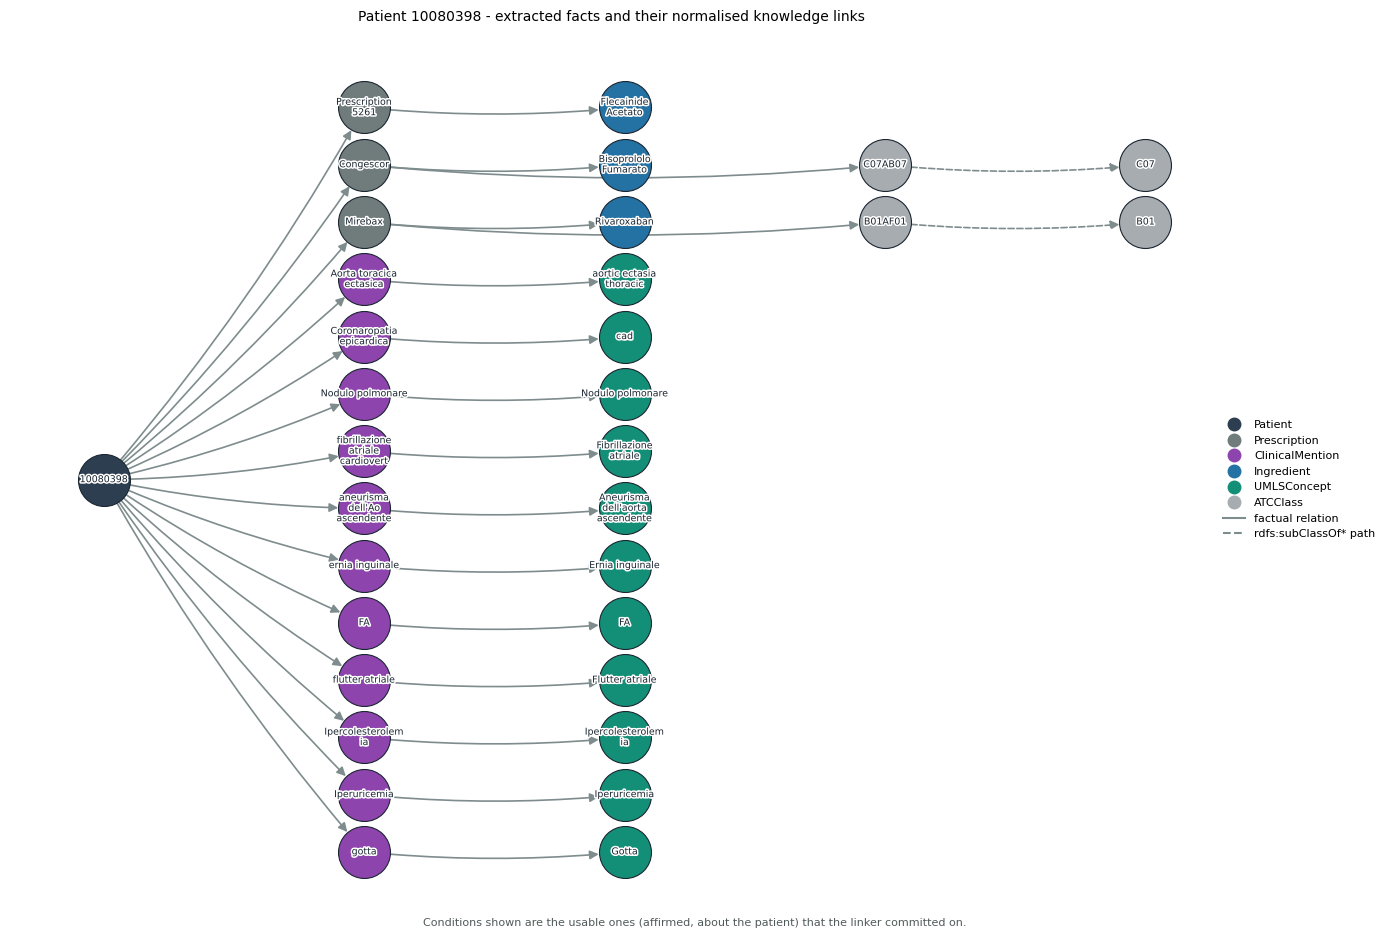

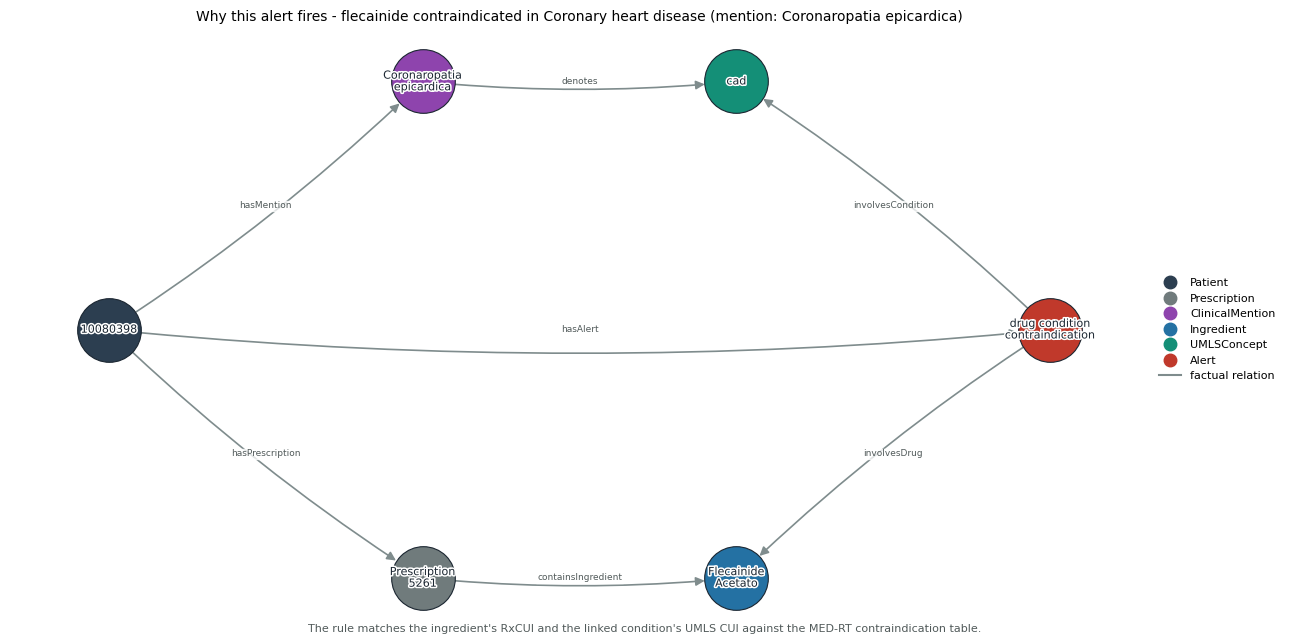

In [57]:
from matplotlib import patheffects

small = {oid for oid, rows in prescribed.groupby("encOid") if rows.prescription_id.nunique() <= 4}
with_chain = set(alerts.loc[alerts.alert_type == "drug_condition_contraindication", "encOid"])
figure_patient = min(sorted(with_chain & small), key=lambda oid: (int((alerts.encOid == oid).sum()), oid))
patient_uri = EX[f"patient_{figure_patient}"]

COLOR = {"Patient": "#2C3E50", "Prescription": "#707B7C", "ClinicalMention": "#8E44AD",
         "Ingredient": "#2471A3", "UMLSConcept": "#148F77", "ATCClass": "#A6ACAF", "Alert": "#C0392B"}


def node_label(node, kind):
    """A short display label; captions and titles carry the full text where it matters."""
    if kind == "Prescription":
        value = kg.value(node, EX.productName) or f"Prescription {str(node).rsplit('_', 1)[-1]}"
    elif kind == "Alert":
        value = str(kg.value(node, EX.alertType)).replace("_", " ")
    else:
        value = kg.value(node, RDFS.label) or str(node).rsplit("/", 1)[-1]

    return textwrap.fill(str(value)[:32], 16)


def render(nodes, edges, position, title, note=None, figsize=(13, 6.5), node_size=2100,
           edge_labels=None):
    """One layered view: `nodes` maps node -> kind, `edges` holds (source, target, dashed)."""
    view = nx.DiGraph()

    for node, kind in nodes.items():
        view.add_node(node, kind=kind, text=node_label(node, kind))

    for source, target, dashed in edges:
        view.add_edge(source, target, dashed=dashed)

    plt.figure(figsize=figsize)

    for kind, color in COLOR.items():
        group = [n for n, d in view.nodes(data=True) if d["kind"] == kind]

        if group:
            nx.draw_networkx_nodes(view, position, nodelist=group, node_color=color, node_size=node_size,
                                   edgecolors="#1B2631", linewidths=0.8)

    for dashed, style in ((False, "solid"), (True, "dashed")):
        group = [(a, b) for a, b, d in view.edges(data=True) if d["dashed"] == dashed]

        if group:
            nx.draw_networkx_edges(view, position, edgelist=group, style=style, edge_color="#7f8c8d",
                                   width=1.2, arrows=True, arrowsize=13, node_size=node_size,
                                   connectionstyle="arc3,rad=0.05")

    texts = nx.draw_networkx_labels(view, position, labels={n: d["text"] for n, d in view.nodes(data=True)},
                                    font_size=6.8 if node_size < 2000 else 8, font_color="#1B2631")

    for text in texts.values():     # a white halo keeps a label readable inside and outside its node
        text.set_path_effects([patheffects.withStroke(linewidth=2.2, foreground="white")])

    if edge_labels:
        nx.draw_networkx_edge_labels(view, position, edge_labels=edge_labels, font_size=6.5,
                                     font_color="#515A5A", rotate=False,
                                     bbox={"alpha": 0.75, "color": "white", "pad": 0.4})

    handles = [plt.Line2D([], [], linestyle="", marker="o", markersize=9, color=color, label=kind)
               for kind, color in COLOR.items() if any(d["kind"] == kind for _, d in view.nodes(data=True))]
    handles.append(plt.Line2D([], [], linestyle="-", color="#7f8c8d", label="factual relation"))

    if any(d["dashed"] for *_, d in view.edges(data=True)):
        handles.append(plt.Line2D([], [], linestyle="--", color="#7f8c8d", label="rdfs:subClassOf* path"))

    plt.legend(handles=handles, loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=8)
    plt.title(title, fontsize=10)

    if note:
        plt.figtext(0.5, 0.02, note, ha="center", fontsize=8, color="#515A5A")

    plt.axis("off")
    plt.tight_layout()
    plt.show()


def atc_class_of(leaf):
    """The three-character ATC ancestor of a leaf code, e.g. C07AB07 -> C07."""
    node = leaf

    while node is not None and len(str(kg.value(node, RDFS.label) or "")) > 3:
        node = kg.value(node, RDFS.subClassOf)

    return node


# View 1 
regimen_rows = []

for prescription in sorted(kg.objects(patient_uri, EX.hasPrescription), key=str):
    ingredients = sorted(kg.objects(prescription, EX.containsIngredient), key=str)
    chains = [(leaf, atc_class_of(leaf)) for leaf in sorted(kg.objects(prescription, EX.atcClass), key=str)]
    regimen_rows.append((prescription, ingredients, chains))

mention_rows = []

for mention in sorted(kg.objects(patient_uri, EX.hasMention), key=str):
    concept = kg.value(mention, EX.denotes)

    if concept is not None and str(kg.value(mention, EX.assertion)) == "affirmed" and str(kg.value(mention, EX.experiencer)) == "patient":
        mention_rows.append((mention, concept))

nodes, edges, position = {patient_uri: "Patient"}, [], {}
row = (len(regimen_rows) + len(mention_rows) - 1) / 2
position[patient_uri] = (0, 0)

for prescription, ingredients, chains in regimen_rows:
    nodes[prescription] = "Prescription"
    position[prescription] = (1, row)
    edges.append((patient_uri, prescription, False))

    for k, ingredient in enumerate(ingredients):
        nodes[ingredient] = "Ingredient"
        position.setdefault(ingredient, (2, row - 0.45 * k))
        edges.append((prescription, ingredient, False))

    for k, (leaf, ancestor) in enumerate(chains):
        nodes[leaf] = "ATCClass"
        position.setdefault(leaf, (3, row - 0.45 * k))
        edges.append((prescription, leaf, False))

        if ancestor is not None and ancestor != leaf:
            nodes[ancestor] = "ATCClass"
            position.setdefault(ancestor, (4, row - 0.45 * k))
            edges.append((leaf, ancestor, True))

    row -= 1

for mention, concept in mention_rows:
    nodes[mention] = "ClinicalMention"
    position[mention] = (1, row)
    edges.append((patient_uri, mention, False))
    nodes[concept] = "UMLSConcept"
    position.setdefault(concept, (2, row))
    edges.append((mention, concept, False))
    row -= 1

render(nodes, edges, position,
       f"Patient {figure_patient} - extracted facts and their normalised knowledge links",
       "Conditions shown are the usable ones (affirmed, about the patient) that the linker committed on.",
       figsize=(14, 9.5), node_size=1400)

# View 2 
alert = sorted((a for a in kg.objects(patient_uri, EX.hasAlert)
                if (a, RDF.type, EX.DrugConditionAlert) in kg), key=str)[0]
drug = kg.value(alert, EX.involvesDrug)
concept = kg.value(alert, EX.involvesCondition)
mention = next(m for m in kg.objects(patient_uri, EX.hasMention) if (m, EX.denotes, concept) in kg)
prescription = next(p for p in kg.objects(patient_uri, EX.hasPrescription)
                    if (p, EX.containsIngredient, drug) in kg)

nodes = {patient_uri: "Patient", prescription: "Prescription", mention: "ClinicalMention",
         drug: "Ingredient", concept: "UMLSConcept", alert: "Alert"}
position = {patient_uri: (0, 0), prescription: (1, -0.55), mention: (1, 0.55),
            drug: (2, -0.55), concept: (2, 0.55), alert: (3, 0)}
edges = [(patient_uri, prescription, False), (patient_uri, mention, False),
         (patient_uri, alert, False), (prescription, drug, False), (mention, concept, False),
         (alert, drug, False), (alert, concept, False)]
edge_names = {(patient_uri, prescription): "hasPrescription", (patient_uri, mention): "hasMention",
              (patient_uri, alert): "hasAlert", (prescription, drug): "containsIngredient",
              (mention, concept): "denotes", (alert, drug): "involvesDrug",
              (alert, concept): "involvesCondition"}

render(nodes, edges, position, f"Why this alert fires - {kg.value(alert, RDFS.label)}",
       "The rule matches the ingredient's RxCUI and the linked condition's UMLS CUI "
       "against the MED-RT contraindication table.", edge_labels=edge_names)


**Output of Section 9.** Every table produced above converges into one artifact: patients,
prescriptions and their ingredients, ATC classes arranged by `rdfs:subClassOf`, anamnesis mentions
with their context and either a concept or a recorded abstention and alerts as nodes that point back
at the entities they were derived from. The queries that are not Q2 could be pandas aggregations over
the same tables; Q2 would need an explicit recursive walk or a hand-written member list, which is
what the property path replaces.

## 10. Local LLM demonstrations

**Task.** Show three ways a small local model can sit next to a symbolic system.

**Method.** `qwen2.5:3b-instruct` through Ollama, at temperature 0, using the same `generate_local`
helper as Section 5.

**Rationale.** These are just demonstrations of a mechanism. Nothing here is scored
against a clinical reference and no clinical fact originates in the model.

The patient used below belongs to the cohort already processed above. These demonstrations show the
path end to end; they say nothing about unseen input.

1. **Grounded verbalisation**: the model receives facts that are already computed and puts them into
   Italian (it decides nothing).
2. **Tool calling over the graph**: the model chooses which symbolic operation to invoke; each tool
   runs a query written and validated here.
3. **Direct SPARQL generation**: the same model asked to write the query itself, checked separately
   for format, validity and correctness.

### 10.1 Grounded verbalisation

In [58]:
demo_patient = int(sorted(alerts.loc[(alerts.alert_type == "drug_drug_interaction")
                                     & (alerts.severity == "Major"), "encOid"].unique())[0])

GROUNDING_RULES = ("Rispondi SOLO con i fatti forniti. Non aggiungere meccanismi farmacologici, "
                   "raccomandazioni o interpretazioni cliniche. Se i fatti non bastano, dillo. "
                   "Massimo 120 parole.")


def facts_for(oid):
    """The structured rows of one patient, unparsed into the plain text that goes into the prompt."""
    drugs = sorted(set(prescribed.loc[prescribed.encOid == oid, "ingredient"].astype(str)))
    usable = conditions_linked[(conditions_linked.encOid == oid) & conditions_linked.usable]
    lines = ["FARMACI ALLA DIMISSIONE: " + ", ".join(drugs),
             "CONDIZIONI AFFERMATE: " + ", ".join(sorted(set(usable.text.astype(str)))[:12])]

    return "\n".join(lines + [f"ALERT [{r.alert_type} | fonte {r.source}]: {r.detail}"
                              for r in alerts[alerts.encOid == oid].itertuples()])


demo_facts = facts_for(demo_patient)
demo_question = "Riassumi le segnalazioni di sicurezza per questo paziente e indica su quali fatti si basano."

print(f"patient {demo_patient}\n")
print(wrap("[system] " + GROUNDING_RULES))
print("\n[user] FATTI:\n" + wrap(demo_facts))
print(wrap("\n[user] DOMANDA: " + demo_question))

demo_answer = generate_local(f"FATTI:\n{demo_facts}\n\nDOMANDA: {demo_question}",
                             system=GROUNDING_RULES)["content"].strip()
print("\n[model]\n" + wrap(demo_answer))

patient 9974566

[system] Rispondi SOLO con i fatti forniti. Non aggiungere meccanismi farmacologici, raccomandazioni
o interpretazioni cliniche. Se i fatti non bastano, dillo. Massimo 120 parole.

[user] FATTI:
FARMACI ALLA DIMISSIONE: Acido acetilsalicilico, Atorvastatina, Clopidogrel, Lacidipina,
Lansoprazolo, Nebivololo, Rivaroxaban
CONDIZIONI AFFERMATE: Dispnea da sforzo, IVU, Ipertensione arteriosa, Macro-adenoma ipofisario, SCA
NSTEMI, adenocarcinoma, adenocarcinoma polmonare, angina atipica, angioTc coronarica, coronaropatia
ostruttiva della destra, diffusa interstiziopatia micronodulare, dispnea da sforzo
ALERT [drug_drug_interaction | fonte DDInter 2.0]: atorvastatina + clopidogrel
ALERT [drug_drug_interaction | fonte DDInter 2.0]: rivaroxaban + clopidogrel

[user] DOMANDA: Riassumi le segnalazioni di sicurezza per questo paziente e indica su quali fatti si
basano.

[model]
I segnalazioni di sicurezza per il paziente sono basate sui farmaci alla dimissione (Acido
acetilsalici

In [59]:
answer_lower = demo_answer.lower()
fact_ingredients = set(prescribed.loc[prescribed.encOid == demo_patient, "ingredient_key"])
named_ingredients = {key for key in PREFERRED_LABEL
                     if len(key) >= 6 and re.search(rf"\b{re.escape(key)}\b", answer_lower)}
fact_severities = {str(s).lower() for s in alerts.loc[alerts.encOid == demo_patient, "severity"]}
named_severities = {word for word in ("major", "moderate", "minor", "grave", "severa", "critica")
                    if word in answer_lower}

print("drugs named but absent from the facts:     ", sorted(named_ingredients - fact_ingredients) or "(none)")
print("severities named but absent from the facts:", sorted(named_severities - fact_severities) or "(none)")

drugs named but absent from the facts:      (none)
severities named but absent from the facts: (none)


### 10.2 Tool calling over the graph

The model never writes a query. It picks a tool and its arguments; each tool runs SPARQL written
here. One of the four questions has no applicable tool and the
only correct behaviour there is to call nothing.

In [60]:
def get_patient_regimen(patient_id):
    """The active ingredients prescribed to one patient at discharge."""
    rows = kg.query(PREFIXES + f"""SELECT DISTINCT ?ingredient WHERE {{
                                     ex:patient_{patient_id} ex:hasPrescription ?p .
                                     ?p ex:containsIngredient ?i . ?i rdfs:label ?ingredient }}""")
    return sorted(str(r[0]) for r in rows) or ["(nessun farmaco)"]


def get_patient_alerts(patient_id):
    """Every alert raised for one patient, as the rule described it."""
    rows = kg.query(PREFIXES + f"""SELECT ?type ?detail WHERE {{
                                     ex:patient_{patient_id} ex:hasAlert ?a .
                                     ?a ex:alertType ?type ; rdfs:label ?detail }}""")
    return [f"{r[0]}: {r[1]}" for r in rows] or ["(nessun alert)"]


def get_drugs_in_atc_class(patient_id, atc_prefix):
    """The patient's drugs under an ATC class, following the hierarchy."""
    rows = kg.query(PREFIXES + f"""SELECT DISTINCT ?ingredient ?code WHERE {{
                                     ex:patient_{patient_id} ex:hasPrescription ?p .
                                     ?p ex:containsIngredient ?i ; ex:atcClass ?c .
                                     ?i rdfs:label ?ingredient .
                                     ?c rdfs:subClassOf* atc:{atc_prefix} ; rdfs:label ?code }}""")
    return [f"{r[0]} ({r[1]})" for r in rows] or [f"(nessun farmaco sotto {atc_prefix})"]


TOOLS = {"get_patient_regimen": get_patient_regimen,
         "get_patient_alerts": get_patient_alerts,
         "get_drugs_in_atc_class": get_drugs_in_atc_class}

TOOL_SPEC = [
    {"type": "function", "function": {
        "name": "get_patient_regimen",
        "description": "Elenca i principi attivi prescritti alla dimissione per un paziente.",
        "parameters": {"type": "object", "properties": {"patient_id": {"type": "string"}},
                       "required": ["patient_id"]}}},
    {"type": "function", "function": {
        "name": "get_patient_alerts",
        "description": "Elenca le segnalazioni di sicurezza di un paziente.",
        "parameters": {"type": "object", "properties": {"patient_id": {"type": "string"}},
                       "required": ["patient_id"]}}},
    {"type": "function", "function": {
        "name": "get_drugs_in_atc_class",
        "description": "Elenca i farmaci del paziente appartenenti a una classe ATC, seguendo la gerarchia "
                       "(C07 = betabloccanti, C10AA = statine, J01C = penicilline).",
        "parameters": {"type": "object", "properties": {"patient_id": {"type": "string"},
                                                        "atc_prefix": {"type": "string"}},
                       "required": ["patient_id", "atc_prefix"]}}},
]

EXPECTED_TOOL = {
    f"Il paziente {demo_patient} assume betabloccanti?": "get_drugs_in_atc_class",
    f"Quali farmaci ha alla dimissione il paziente {demo_patient}?": "get_patient_regimen",
    f"Che segnalazioni di sicurezza ha il paziente {demo_patient}?": "get_patient_alerts",
    f"Qual è la pressione arteriosa del paziente {demo_patient}?": None,
}

In [61]:
ROUTING_RULES = "Scegli lo strumento adatto. Non inventare dati. Se nessuno strumento puo rispondere, dillo."
ANSWER_RULES = ("I FATTI elencati sono il risultato completo dello strumento interrogato sulla "
                "cartella del paziente nominato nella domanda. Rispondi alla domanda usando SOLO "
                "questi fatti. Non aggiungere meccanismi farmacologici, raccomandazioni o "
                "interpretazioni cliniche. Massimo 120 parole.")
trace = []

for question, expected in EXPECTED_TOOL.items():
    print("\n" + "-" * 90 + f"\nQ: {question}")
    message = generate_local(question, system=ROUTING_RULES, tools=TOOL_SPEC)
    calls = message.get("tool_calls") or []

    if not calls:
        print(wrap("   [no tool selected] " + message["content"].strip()))
        trace.append({"question": question[:48], "expected": expected or "(none)", "selected": "(none)",
                      "routed correctly": expected is None, "answer uses the facts": None})
        continue

    name = calls[0]["function"]["name"]
    arguments = dict(calls[0]["function"].get("arguments") or {})
    returned = TOOLS[name](**arguments) if name in TOOLS else ["(strumento inesistente)"]
    print(wrap(f"   [tool] {name}({arguments})\n   [facts] {returned}"))

    facts_text = f"FATTI del paziente {demo_patient}:\n" + "\n".join(f"- {fact}" for fact in returned)
    answer = generate_local(f"{facts_text}\n\nDOMANDA: {question}", system=ANSWER_RULES)["content"].strip()
    print(wrap("   [answer] " + answer))
    
    vocabulary = {w.lower() for fact in returned for w in re.findall(r"[A-Za-zÀ-ÿ]{6,}", str(fact))}
    trace.append({"question": question[:48], "expected": expected or "(none)", "selected": name,
                  "routed correctly": name == expected and str(demo_patient) in str(arguments),
                  "answer uses the facts": any(w in answer.lower() for w in vocabulary)})

routing = pd.DataFrame(trace)
display(routing)
print(f"routing: {int(routing['routed correctly'].sum())}/{len(routing)} questions sent to the expected "
      f"tool (the unanswerable one counts only when no tool is called)")
print(f"use of the returned facts: {int(routing['answer uses the facts'].fillna(False).sum())}/"
      f"{int(routing['answer uses the facts'].notna().sum())} answers repeat one")


------------------------------------------------------------------------------------------
Q: Il paziente 9974566 assume betabloccanti?
   [tool] get_drugs_in_atc_class({'atc_prefix': 'C07', 'patient_id': '9974566'})
   [facts] ['Nebivololo (C07AB12)']
   [answer] Sì, il paziente 9974566 assume nebivololo (C07AB12), che è un betablocco.

------------------------------------------------------------------------------------------
Q: Quali farmaci ha alla dimissione il paziente 9974566?
   [tool] get_patient_regimen({'patient_id': '9974566'})
   [facts] ['Acido Acetilsalicilico', 'Atorvastatina', 'Clopidogrel', 'Lacidipina', 'Lansoprazolo',
'Nebivololo', 'Rivaroxaban']
   [answer] Acido Acetilsalicilico
Atorvastatina
Clopidogrel
Lacidipina
Lansoprazolo
Nebivololo
Rivaroxaban

------------------------------------------------------------------------------------------
Q: Che segnalazioni di sicurezza ha il paziente 9974566?
   [tool] get_patient_alerts({'patient_id': '9974566'})
   [facts] [

,question,expected,selected,routed correctly,answer uses the facts
0,Il paziente 9974566 assume betabloccanti?,get_drugs_in_atc_class,get_drugs_in_atc_class,True,True
1,Quali farmaci ha alla dimissione il paziente 997,get_patient_regimen,get_patient_regimen,True,True
2,Che segnalazioni di sicurezza ha il paziente 997,get_patient_alerts,get_patient_alerts,True,True
3,Qual è la pressione arteriosa del paziente 99745,(none),(none),True,None


routing: 4/4 questions sent to the expected tool (the unanswerable one counts only when no tool is called)
use of the returned facts: 3/3 answers repeat one


### 10.3 The same model asked to write SPARQL

Four checks grouped into three questions, because they fail differently: did the output obey the
requested format, is the query it contains valid (does it parse, does it execute) and does it answer
what was asked.

In [62]:
SCHEMA_DESCRIPTION = ("Classi: ex:Patient, ex:Prescription, ex:Ingredient, ex:ATCClass, ex:Alert. "
                      "Proprieta: ex:hasPrescription, ex:containsIngredient, ex:atcClass, ex:hasAlert, "
                      "ex:alertType, rdfs:label. Prefisso ex: <http://example.org/clinical/>.")

raw_answer = generate_local(f"Schema RDF: {SCHEMA_DESCRIPTION}\nScrivi SOLO una query SPARQL che elenchi "
                            f"i principi attivi del paziente ex:patient_{demo_patient}.")["content"]
print("model output:\n")
print(wrap(raw_answer[:700]))

fenced = re.search(r"```(?:sparql)?\s*(.*?)```", raw_answer, flags=re.DOTALL | re.IGNORECASE)
query_text = fenced.group(1).strip() if fenced else raw_answer.strip()
obeyed_format = query_text == raw_answer.strip()

parses = executes = False
failure = ""

try:
    prepareQuery(query_text)
    parses = True
except Exception as error:              # rdflib reports every syntax problem as an exception
    failure = f"parse: {type(error).__name__}: {str(error)[:110]}"

if parses:
    try:
        returned = list(kg.query(query_text))
        executes = True
    except Exception as error:
        returned = []
        failure = f"execution: {type(error).__name__}: {str(error)[:110]}"
else:
    returned = []

expected_rows = list(kg.query(PREFIXES + f"""SELECT ?i ?label WHERE {{
                                               ex:patient_{demo_patient} ex:hasPrescription ?p .
                                               ?p ex:containsIngredient ?i . ?i rdfs:label ?label }}"""))
expected_uris = {str(r[0]) for r in expected_rows}
expected_labels = {str(r[1]) for r in expected_rows}
returned_values = {str(value) for row in returned for value in row if value is not None}
# The query answers the question when what it returns IS the patient's ingredients, as node URIs
# or as labels. A subset would be incomplete and a superset would be another patient's drugs too.
answers_question = bool(expected_uris) and returned_values in (expected_uris, expected_labels)

display(pd.DataFrame([
    {"check": "the output is a query and nothing else", "result": obeyed_format},
    {"check": "the extracted query parses", "result": parses},
    {"check": "it executes against this graph", "result": executes},
    {"check": "it returns the patient's ingredients", "result": answers_question},
]).set_index("check"))

if failure:
    print(failure)
else:
    print(f"rows returned: {len(returned)} | expected ingredients: {len(expected_uris)}")

model output:

Per ottenere la lista dei principi attivi (ingredienti) di un paziente specifico, puoi utilizzare la
seguente query SPARQL:

```sparql
PREFIX ex: <http://example.org/clinical/>
SELECT ?ingredient WHERE {
  ex:patient_9974566 ex:hasPrescription ?prescription .
  ?prescription ex:containsIngredient ?ingredient .
}
```

Questa query seleziona tutti gli ingredienti (ex:ingredient) che sono contenuti in una prescrizione
(ex:hasPrescription) del paziente con l'ID specificato (ex:patient_9974566).


,result
check,
the output is a query and nothing else,False
the extracted query parses,True
it executes against this graph,True
it returns the patient's ingredients,True


rows returned: 7 | expected ingredients: 7


## 11. Discussion

**Method follows surface form.** The three reports needed three techniques:

- *Terapia alla Dimissione* is a filled template, so a regex reads it and
  scores near the ceiling.
- *Terapia medica all'ingresso* has no stable shape, so a compact few-shot
  extractor covers its variants with one prompt.
- *Anamnesi* is open-ended free prose, so the project handles it with zero-shot NER, a context
  algorithm and an entity linker and it is the least accurate stage of the three.

**Two context axes.** Assertion and experiencer are the axes the project models, because Italian
clinical writing marks them with explicit lexical cues that ConText's sentence scope can reach. 
They are also the two the alert engine is based on: a condition gates a rule only when it is 
affirmed and about the patient.

**Dependency parsing was explored.** Section 6.3 parses two real negated sentences and
prints, per condition, whether the cue's subtree reaches it. Where the cue is the verb, the subtree
covers both coordinated conditions; where the negation attaches as an adverbial modifier, the subtree
is the cue alone and reaches nothing. 

**The alerts are new facts.** Each one is derived from premises that live in different places (two
reports and an external table) and is written in none of them. 

**Long chains break first.** The duplicate rule joins on an ingredient identity the discharge
template states directly; the interaction rule adds one mapping step, from that ingredient to a
DDInter identifier the report never carries. The drug-condition rule sits behind two linking steps: an
Italian phrase to a UMLS concept and a MeSH descriptor to the same vocabulary. Section 8.6 runs the
same four functions on annotated and on extracted inputs (the annotated run takes its concepts from
the UMLS reference annotation, so linking error propagates into the comparison too) and its table is
where an upstream error becomes a different alert. 

**What RDF adds.** One artifact instead of a folder of tables and an explicit hierarchy with a
declarative way to walk it: `rdfs:subClassOf*` retrieves ATC class membership that no triple states.

**Three jobs for the LLM.** It extracts admission mentions, verbalises facts that are already computed,
and chooses which validated query to run. It is never the source of a clinical assertion: every
interaction comes from DDInter, every contraindication from MED-RT, every linked condition identity from UMLS.

**Limits.** The main ones:

- *In what the pipeline models*: prescriptions written outside the quoted discharge block are not
  extracted; treatment status is not modelled, so an entry whose instructions mention a suspension
  is extracted like any other and the instruction text is kept but never read; allergen mentions
  that name a class rather than a substance stay unresolved.
- *In the external knowledge*: rule recall is bounded by identifier coverage.
- *In the evaluation*: one small reference annotation set with no inter-annotator agreement.

None of the linking output is suitable for clinical use.